# Sistema de Búsqueda de Estudiantes: Lista, ABB y Árbol B+

Importaciones y datos del equipo donde se ejecutaron las pruebas.

In [1]:
# Importación de herramientas necesarias
import random
import time
import math
import statistics
from bisect import bisect_right, bisect_left
from faker import Faker
import matplotlib.pyplot as plt
import gc
import os
import numpy as np
from scipy import stats

SEMILLA = 42  # Semilla fija para que los datos sean reproducibles

Datos del equipo dónde se ejecuto el estudio

In [2]:
# Datos del entorno de ejecución (hardware y software)
import platform
import psutil
import cpuinfo
import faker
import matplotlib
import numpy
import scipy

info_cpu = cpuinfo.get_cpu_info()
frecuencia = psutil.cpu_freq()
memoria = psutil.virtual_memory()

print("=== HARDWARE ===")
print(f"Procesador          : {info_cpu.get('brand_raw', platform.processor())}")
print(f"Arquitectura        : {platform.machine()}")
print(f"Núcleos físicos     : {psutil.cpu_count(logical=False)}")
print(f"Núcleos lógicos     : {psutil.cpu_count(logical=True)}")
if frecuencia:
    print(f"Frecuencia CPU (MHz): actual {frecuencia.current:.0f} | máx {frecuencia.max:.0f}")
print(f"RAM total           : {memoria.total / 1024**3:.1f} GB")
print(f"RAM disponible      : {memoria.available / 1024**3:.1f} GB")
print(f"Carga de CPU ahora  : {psutil.cpu_percent(interval=1):.1f} %")

print("\n=== SOFTWARE ===")
print(f"Sistema operativo   : {platform.system()} {platform.release()} ({platform.version()})")
print(f"Python              : {platform.python_version()} ({platform.python_implementation()})")
print(f"Faker               : {faker.VERSION}")
print(f"Matplotlib          : {matplotlib.__version__}")
print(f"NumPy              : {numpy.__version__}")
print(f"SciPy              : {scipy.__version__}")

=== HARDWARE ===
Procesador          : 13th Gen Intel(R) Core(TM) i5-13420H
Arquitectura        : AMD64
Núcleos físicos     : 8
Núcleos lógicos     : 12
Frecuencia CPU (MHz): actual 2100 | máx 2100
RAM total           : 15.6 GB
RAM disponible      : 5.2 GB
Carga de CPU ahora  : 10.0 %

=== SOFTWARE ===
Sistema operativo   : Windows 11 (10.0.26200)
Python              : 3.14.3 (CPython)
Faker               : 40.39.0
Matplotlib          : 3.11.2
NumPy              : 2.5.3
SciPy              : 1.18.1


## Enunciado: **Sistema de Búsqueda de Estudiantes**

Tienes un archivo con 10,000 estudiantes (nombre, edad,
promedio). Necesitas implementar un sistema que
permita:
1. Buscar un estudiante por su ID (número de matrícula)
2. Insertar nuevos estudiantes
3. Listar todos los estudiantes en orden ascendente por ID

In [3]:
# Entidad Estudiante
class Estudiante:
    def __init__(self, id, nombre, edad, promedio) -> None:
        self.Id = id
        self.Nombre = nombre
        self.edad = edad
        self.Promedio = promedio
    
    def __repr__(self):
        return f"ID: {self.Id} - Nombre: {self.Nombre} - Edad: {self.edad} - Promedio: {self.Promedio}"

In [4]:
# Semillas fijas (reproducibilidad)
random.seed(SEMILLA)
Faker.seed(SEMILLA)

# Inicializar Faker
fake = Faker('es_MX')

def generar_dataset(tamano, id_inicial = 1000, ordenado = False):
    ids_estudiantes = list(range(id_inicial, id_inicial+tamano))
    if not ordenado:
        random.shuffle(ids_estudiantes)
    
    estudiantes = []
    
    for est_id in ids_estudiantes:
        estudiante = Estudiante(id=est_id, nombre=fake.name(), edad= random.randint(16, 30) ,promedio= round(random.uniform(0, 5), 1))
        estudiantes.append(estudiante)
    
    return estudiantes
    
# Creación del Dataset para pruebas inciales
cantidad_estudiantes = 10000
estudiantes = generar_dataset(cantidad_estudiantes)
estudiantes_ordenados = generar_dataset(cantidad_estudiantes, ordenado=True)

## Implementaciones

In [5]:
# Implementación con lista nativa

class ListaEstudiantes:
    def __init__(self):
        self.estudiantes = []
    
    def insertar(self, estudiante):
        self.estudiantes.append(estudiante)
    
    def buscar(self, id):
        for est in self.estudiantes:
            if est.Id == id:
                return est
        return None
    
    def listar_ordenado(self):
        return sorted(self.estudiantes, key= lambda est: est.Id)
    
    def buscar_rango(self, id_i, id_f):
        return [est for est in self.estudiantes if id_i <= est.Id <= id_f]

In [6]:
# Implementación con ABB co-generado con copilot

class NodoABB:
    def __init__(self, estudiante) -> None:
        self.estudiante = estudiante
        self.izq = None
        self.der = None

class ABB:
    def __init__(self) -> None:
        self.root = None
    
    def insertar(self, estudiante):
        nuevo_nodo = NodoABB(estudiante)

        # Si el árbol está vacío
        if self.root is None:
            self.root = nuevo_nodo
            return
        
        nodo_actual = self.root

        while True:
            # No se insertan IDs duplicados, en este caso se actualiza el estudiante
            if estudiante.Id == nodo_actual.estudiante.Id:
                nodo_actual.estudiante = estudiante
                return
            # Ir hacia la izquierda
            if estudiante.Id < nodo_actual.estudiante.Id:
                if nodo_actual.izq is None:
                    nodo_actual.izq = nuevo_nodo
                    return

                nodo_actual = nodo_actual.izq
            # Ir hacia la derecha
            else:
                if nodo_actual.der is None:
                    nodo_actual.der = nuevo_nodo
                    return

                nodo_actual = nodo_actual.der
    
    def buscar(self, id):
        actual = self.root
        while actual is not None:
            if id == actual.estudiante.Id:
                return actual.estudiante
            if id < actual.estudiante.Id:
                actual = actual.izq
            elif id > actual.estudiante.Id:
                actual = actual.der
        return None
    
    def listar_ordenado(self):
        resultado = []
        pila = []
        nodo_actual = self.root

        # Recorrido inorden iterativo
        while pila or nodo_actual is not None:
            while nodo_actual is not None:
                pila.append(nodo_actual)
                nodo_actual = nodo_actual.izq

            nodo_actual = pila.pop()
            resultado.append(nodo_actual.estudiante)

            nodo_actual = nodo_actual.der

        return resultado
    
    def buscar_rango(self, id_i, id_f):
        resultado = []
        pila = []
        actual = self.root
        
        while True:
            if actual is not None:
                pila.append(actual)
                if actual.estudiante.Id >= id_i:
                    actual = actual.izq
                else:
                    actual = None
            elif pila:
                actual = pila.pop()
                if id_i <= actual.estudiante.Id <= id_f:
                    resultado.append(actual.estudiante)
                if actual.estudiante.Id < id_f:
                    actual = actual.der
                else:
                    actual = None
            else:
                break
        
        return resultado
    
    def altura(self):
            # Altura = número de niveles del árbol (iterativo: con IDs ordenados la altura llega a N)
            if self.root is None:
                return 0
            maximo, pila = 0, [(self.root, 1)]
            while pila:
                nodo, nivel = pila.pop()
                maximo = max(maximo, nivel)
                if nodo.izq is not None:
                    pila.append((nodo.izq, nivel + 1))
                if nodo.der is not None:
                    pila.append((nodo.der, nivel + 1))
            return maximo

La siguiente implementación del árbol B+ fue ajustada para el ejercicio a partir de la implementación publicada en [programiz](https://www.programiz.com/dsa/b-plus-tree).

**Ajustes realizados**

- Se cambió la comparación de los valores de tipo `string` a valores de tipo `int`, debido a que los IDs utilizados son números enteros y deben compararse numéricamente
- Se eliminó la agrupación de múltiples claves por valor, ya que cada estudiante posee un ID único
- Se agregó el método `buscar(id_estudiante)`, que devuelve directamente el estudiante asociado al ID indicado
- Se agregó el método `listar_ordenado()`, que recorre las hojas enlazadas mediante `nextKey` y devuelve los estudiantes ordenados por ID
- Se agregó el método `buscar_rango(id_i, id_f)`, que desciende por el árbol una única vez hasta encontrar el punto de partida y luego recorrer las hojas enlazadas hasta el id final
- Se agregó el método `altura()`, que cuenta los niveles desde la raíz hasta las hojas (se usa para relacionar la altura con el tiempo de búsqueda)

In [7]:
# Implementación con Árbol B+

class NodoBplus:
    def __init__(self, order):
        self.order = order
        self.values = [] # En hojas: IDs; en nodos internos: separadores
        self.keys = [] # En hojas: estudiantes; en nodos internos: hijos
        self.nextKey = None # Enlace entre hojas
        self.parent = None
        self.checkLeaf = False

    def insert_at_leaf(self, leaf, value, estudiante):
        if self.values:
            for i in range(len(self.values)):
                if value == self.values[i]:
                    # Si el ID ya existes se actualiza el estudiante
                    self.keys[i] = estudiante
                    return
                elif value < self.values[i]:
                    self.values.insert(i, value)
                    self.keys.insert(i, estudiante)
                    return
                elif i+ 1 == len(self.values):
                    self.values.append(value)
                    self.keys.append(estudiante)
                    return
        else:
            self.values = [value]
            self.keys = [estudiante]

class BplusTree:
    def __init__(self, order) -> None:
        self.root = NodoBplus(order)
        self.root.checkLeaf = True
    
    def insertar(self, estudiante):
        value = estudiante.Id
        old_node = self.search(value)
        old_node.insert_at_leaf(old_node, value, estudiante)
        
        if len(old_node.values) == old_node.order:
            node1 = NodoBplus(old_node.order)
            node1.checkLeaf = True
            node1.parent = old_node.parent
            
            mid = int(math.ceil(old_node.order/2))-1
            
            # Parte derecha se mueve a la nueva hoja
            node1.values = old_node.values[mid + 1:]
            node1.keys = old_node.keys[mid + 1:]
            node1.nextKey = old_node.nextKey

            # Parte izquierda se queda en la hoja vieja
            old_node.values = old_node.values[:mid + 1]
            old_node.keys = old_node.keys[:mid + 1]
            old_node.nextKey = node1
            
            self.insert_in_parent(old_node, node1.values[0], node1)
    
    def search(self, value):
        current_node = self.root

        while current_node.checkLeaf == False:
            # bisect_right nos da directamente el índice del puntero hijo que debemos seguir
            i = bisect_right(current_node.values, value)
            current_node = current_node.keys[i]

        return current_node
    
    def buscar(self, id):
        node = self.search(id) # Hoja donde deberia encontrarse
        # Buscamos la posición exacta del ID dentro de la hoja
        i = bisect_left(node.values, id)
        
        if i < len(node.values) and node.values[i] == id:
            return node.keys[i]
        
        return None
    
    def listar_ordenado(self):
        resultado = []

        nodo = self.root
        while nodo.checkLeaf == False:
            nodo = nodo.keys[0]

        while nodo is not None:
            for estudiante in nodo.keys:
                resultado.append(estudiante)
            nodo = nodo.nextKey

        return resultado
    
    def insert_in_parent(self, n, value, ndash):
        if self.root == n:
            rootNode = NodoBplus(n.order)
            rootNode.values = [value]
            rootNode.keys = [n, ndash]
            self.root = rootNode
            n.parent = rootNode
            ndash.parent = rootNode
            return

        parentNode = n.parent

        for i in range(len(parentNode.keys)):
            if parentNode.keys[i] == n:
                parentNode.values = parentNode.values[:i] + [value] + parentNode.values[i:]
                parentNode.keys = parentNode.keys[:i + 1] + [ndash] + parentNode.keys[i + 1:]

                if len(parentNode.keys) > parentNode.order:
                    parentdash = NodoBplus(parentNode.order)
                    parentdash.parent = parentNode.parent

                    mid = int(math.ceil(parentNode.order / 2)) - 1

                    parentdash.values = parentNode.values[mid + 1:]
                    parentdash.keys = parentNode.keys[mid + 1:]

                    value_ = parentNode.values[mid]

                    if mid == 0:
                        parentNode.values = parentNode.values[:mid + 1]
                    else:
                        parentNode.values = parentNode.values[:mid]

                    parentNode.keys = parentNode.keys[:mid + 1]

                    for j in parentNode.keys:
                        j.parent = parentNode

                    for j in parentdash.keys:
                        j.parent = parentdash

                    self.insert_in_parent(parentNode, value_, parentdash)

                return
    
    def buscar_rango(self, id_i, id_f):
        resultado = []
        
        actual = self.search(id_i)
        
        if actual is None:
            return resultado
        
        while actual is not None:
            for i in range(len(actual.values)):
                id_guardado = actual.values[i]
                if id_i <= id_guardado <= id_f:
                    resultado.append(actual.keys[i])
                elif id_guardado > id_f:
                    return resultado
            actual = actual.nextKey
        
        return resultado
    
    def altura(self):
            # En un B+ todas las hojas están al mismo nivel: basta bajar por el primer hijo
            nivel, nodo = 1, self.root
            while not nodo.checkLeaf:
                nodo = nodo.keys[0]
                nivel += 1
            return nivel
        

## Construcción y validación manual

Se llenan las tres estructuras con el dataset generado y se hace una prueba inicial de búsqueda, recorrido ordenado e inserción.

In [8]:
# Construción de estructuras llenadas con el dataset generado en principio
def construir_estructuras(estudiantes, order=8):
    lista = ListaEstudiantes()
    abb = ABB()
    abplus = BplusTree(order=order)
    for estudiante in estudiantes:
        lista.insertar(estudiante)
        abb.insertar(estudiante)
        abplus.insertar(estudiante)
    
    return lista, abb, abplus

lista, abb, abplus = construir_estructuras(estudiantes)

In [9]:
prueba_id = estudiantes[42].Id

print(f"PRUEBA DE BÚSQUEDA (ID: {prueba_id})")
print("En Lista Nativa :", lista.buscar(prueba_id))
print("En Árbol ABB    :", abb.buscar(prueba_id))
print("En Árbol B+     :", abplus.buscar(prueba_id))

print(f"PRUEBA DE RECORRIDO EN B+")
primeros_5 = abplus.listar_ordenado()[:5]
for est in primeros_5:
    print(est)
    
print(f"PRUEBA DE INSERCIÓN EN B+")
nuevo_id = 99999
estudiante_nuevo = Estudiante(id=nuevo_id, nombre="Ada Lovelace", edad=20, promedio=5.0)

abplus.insertar(estudiante_nuevo)
print("Buscando estudiante recién insertado:", abplus.buscar(nuevo_id))

PRUEBA DE BÚSQUEDA (ID: 1704)
En Lista Nativa : ID: 1704 - Nombre: Rufino Berríos - Edad: 29 - Promedio: 0.3
En Árbol ABB    : ID: 1704 - Nombre: Rufino Berríos - Edad: 29 - Promedio: 0.3
En Árbol B+     : ID: 1704 - Nombre: Rufino Berríos - Edad: 29 - Promedio: 0.3
PRUEBA DE RECORRIDO EN B+
ID: 1000 - Nombre: Gonzalo Uriel Becerra Hernádez - Edad: 20 - Promedio: 4.0
ID: 1001 - Nombre: Esmeralda Nájera Jasso - Edad: 20 - Promedio: 3.2
ID: 1002 - Nombre: Ángel Reynoso Soria - Edad: 19 - Promedio: 3.6
ID: 1003 - Nombre: Raquel Meza Amaya - Edad: 25 - Promedio: 4.6
ID: 1004 - Nombre: Hugo Mario Rubio Casas - Edad: 28 - Promedio: 1.6
PRUEBA DE INSERCIÓN EN B+
Buscando estudiante recién insertado: ID: 99999 - Nombre: Ada Lovelace - Edad: 20 - Promedio: 5.0


### Validación automática

Prueba que las tres estructuras coinciden (búsqueda, IDs inexistentes, listado y rango) con datasets aleatorios y ordenados y con distintos órdenes del B+. Si algo falla, se detiene con un `AssertionError`.

In [10]:
# Validación automática: las tres estructuras deben dar los mismos resultados (Generado con Clude Sonnet 5.5)
def validar(estudiantes, order=8):
    lista, abb, bplus = construir_estructuras(estudiantes, order)
    ids = sorted(e.Id for e in estudiantes)

    # 1. Todo ID insertado se encuentra y devuelve el mismo estudiante
    for est in estudiantes:
        assert lista.buscar(est.Id) is est
        assert abb.buscar(est.Id) is est
        assert bplus.buscar(est.Id) is est

    # 2. IDs inexistentes devuelven None (se usa x.5 porque los IDs son enteros)
    for id_falso in (ids[0] - 1, ids[-1] + 1, ids[len(ids) // 2] + 0.5):
        assert lista.buscar(id_falso) is None
        assert abb.buscar(id_falso) is None
        assert bplus.buscar(id_falso) is None

    # 3. El listado sale en orden ascendente de ID en las tres estructuras
    for estructura in (lista, abb, bplus):
        assert [e.Id for e in estructura.listar_ordenado()] == ids

    # 4. La búsqueda por rango devuelve los mismos elementos en las tres
    id_i, id_f = ids[len(ids) // 10], ids[len(ids) // 2]
    esperado = [i for i in ids if id_i <= i <= id_f]
    for estructura in (lista, abb, bplus):
        assert sorted(e.Id for e in estructura.buscar_rango(id_i, id_f)) == esperado

for n in (1, 2, 10, 500, 2000):
    validar(generar_dataset(n))
    validar(generar_dataset(n, ordenado=True))
for orden in (4, 8, 16, 32, 64, 128):   # el B+ debe ser correcto para todos los órdenes que se van a probar
    validar(generar_dataset(2000), order=orden)
    validar(generar_dataset(2000, ordenado=True), order=orden)

print("Validación automática superada: las tres estructuras coinciden en búsqueda, listado y rango.")

Validación automática superada: las tres estructuras coinciden en búsqueda, listado y rango.


## Experimentos

Bloque de experimentación y generación de gráficas generado con Gemini 3.1 Pro.

---

### Herramientas de medición y estadística

En esta sección se definen las constantes y funciones comunes para todos los experimentos. Centralizar este código asegura que todas las pruebas sean reproducibles y se midan exactamente bajo las mismas condiciones.

In [11]:
# Herramientas comunes para medir y resumir los experimentos
os.makedirs("graficas", exist_ok=True)   # Aquí se guardan las gráficas
REPETICIONES = 10                   # Repeticiones por defecto en cada experimento

ESTILOS = {
    "lista": ("red", "o", "Lista Nativa"),
    "abb": ("orange", "s", "Árbol ABB"),
    "bplus": ("green", "^", "Árbol B+"),
}

def insertar_todos(estructura, estudiantes):
    for est in estudiantes:
        estructura.insertar(est)

def buscar_todos(estructura, ids):
    for id_b in ids:
        estructura.buscar(id_b)

def cronometrar(funcion, *args):
    """Mide el tiempo (s) con perf_counter y el recolector de basura desactivado (como hace timeit)."""
    gc.collect()
    gc.disable()
    try:
        inicio = time.perf_counter()
        funcion(*args)
        return time.perf_counter() - inicio
    finally:
        gc.enable()

def medir_busqueda(estructura, ids):
    """Calentamiento (100 búsquedas sin medir) y luego medición del lote completo."""
    buscar_todos(estructura, ids[:100])
    return cronometrar(buscar_todos, estructura, ids)

def resumen(tiempos, escala=1.0):
    """Estadísticas de una lista de tiempos (multiplicados por 'escala' para cambiar de unidad)."""
    datos = np.array(tiempos, dtype=float) * escala
    n = len(datos)
    media = float(datos.mean())
    std = float(datos.std(ddof=1)) if n > 1 else 0.0                       # desviación estándar muestral
    ic95 = float(stats.t.ppf(0.975, n - 1) * std / math.sqrt(n)) if n > 1 else 0.0   # IC 95 % (t de Student)
    q1, q3 = np.percentile(datos, [25, 75])
    iqr = q3 - q1
    atipicos = int(np.sum((datos < q1 - 1.5 * iqr) | (datos > q3 + 1.5 * iqr)))        # criterio de Tukey (se reportan, no se eliminan)
    return {"n": n, "media": media, "std": std, "mediana": float(np.median(datos)), "ic95": ic95, "atipicos": atipicos}

def pendiente_loglog(x, y):
    """Pendiente de log(y) vs log(x): ~1 lineal, ~2 cuadrático, cercana a 0 casi constante o logarítmico."""
    return float(np.polyfit(np.log(x), np.log(y), 1)[0])

def r2(x, y):
    """Coeficiente de determinación R² de una regresión lineal y ~ x."""
    return float(stats.linregress(x, y).rvalue ** 2)

def imprimir_tabla(titulo_x, xs, series, unidad):
    """Tabla con media ± desviación estándar [mediana] de cada serie."""
    print(f"Media ± desv. estándar [mediana], en {unidad}")
    print(f"{titulo_x:>10} | " + " | ".join(f"{nombre:^32}" for nombre in series))
    for i, x in enumerate(xs):
        celdas = []
        for serie in series.values():
            r = serie[i]
            texto = "—" if r is None else f"{r['media']:.4g} ± {r['std']:.2g} [{r['mediana']:.4g}]"
            celdas.append(f"{texto:^32}")
        print(f"{str(x):>10} | " + " | ".join(celdas))
    print()

def graficar_series(ax, xs, series, claves=("lista", "abb", "bplus")):
    """Dibuja media ± desviación estándar de cada estructura (omite los puntos sin dato)."""
    for k in claves:
        color, marcador, etiqueta = ESTILOS[k]
        puntos = [(x, r) for x, r in zip(xs, series[k]) if r is not None]
        ax.errorbar([x for x, _ in puntos], [r["media"] for _, r in puntos],
                    yerr=[r["std"] for _, r in puntos], fmt="-" + marcador,
                    color=color, label=etiqueta, capsize=4, linewidth=2)

def guardar_grafica(nombre):
    plt.savefig(f"graficas/{nombre}.png", dpi=150, bbox_inches="tight")

### Experimento 1: Impacto del orden de inserción en la degeneración del ABB vs. Estabilidad del B+

El objetivo de este experimento es demostrar la susceptibilidad teórica del Árbol Binario de Busqueda (ABB) al insertar datos secuenciales: se degenera en una estructura parecida a una lista enlazada, pierde su eficiencia logarítmica y su altura llega al máximo. También se quiere relacionar la altura del árbol con el tiempo de búsqueda. El B+ se autobalancea y sirve como contraste.

Se varía $N \in [500; 1,000; 2,000; 5,000; 10,000; 20,000]$ y se fija $M = 1,000$ búsquedas por repetición (IDs existentes elegidos al azar). Para cada $N$ se evalúan dos casos:

- **IDs aleatorios:** en cada una de las 10 repeticiones se genera un dataset nuevo y se reconstruyen los árboles, para capturar la variabilidad de la forma del ABB.
- **IDs ordenados:** la forma de los árboles es siempre la misma (es determinista). Se construyen 3 veces para medir el tiempo de construcción y se hacen 10 repeticiones de las $M$ búsquedas con muestras de IDs distintas.

Se registran, por estructura: tiempo por búsqueda (µs), tiempo de construcción (s) y altura del árbol. Se omite la lista nativa porque su búsqueda es $O(N)$ sin importar el orden. El máximo es $N = 20,000$ porque construir un ABB con datos ordenados cuesta $O(N^2)$.

In [12]:
def construir_medir(estudiantes):
    """Construye ABB y B+ midiendo el tiempo de construcción de cada uno."""
    abb, bplus = ABB(), BplusTree(order=8)
    t_abb = cronometrar(insertar_todos, abb, estudiantes)
    t_bplus = cronometrar(insertar_todos, bplus, estudiantes)
    return abb, bplus, t_abb, t_bplus

def evaluar_caso(n, ordenado, num_busquedas, repeticiones, reps_construccion_ordenado=3):
    """Tiempos de construcción, de búsqueda y altura de ABB y B+ para un N y un tipo de orden."""
    t_cons = {"abb": [], "bplus": []}
    t_busq = {"abb": [], "bplus": []}
    alturas = {"abb": [], "bplus": []}

    if ordenado:
        # Un único dataset: el orden creciente siempre produce la misma forma de árbol
        estudiantes = generar_dataset(n, ordenado=True)
        for _ in range(reps_construccion_ordenado):
            abb, bplus, t_abb, t_bplus = construir_medir(estudiantes)
            t_cons["abb"].append(t_abb)
            t_cons["bplus"].append(t_bplus)

    for _ in range(repeticiones):
        if not ordenado:
            # Dataset nuevo en cada repetición: captura la variabilidad de la forma del árbol
            estudiantes = generar_dataset(n)
            abb, bplus, t_abb, t_bplus = construir_medir(estudiantes)
            t_cons["abb"].append(t_abb)
            t_cons["bplus"].append(t_bplus)

        ids = random.choices([est.Id for est in estudiantes], k=num_busquedas)
        t_busq["abb"].append(medir_busqueda(abb, ids))
        t_busq["bplus"].append(medir_busqueda(bplus, ids))
        alturas["abb"].append(abb.altura())
        alturas["bplus"].append(bplus.altura())

    escala = 1e6 / num_busquedas   # segundos por lote -> µs por búsqueda
    return {est: {"busqueda": resumen(t_busq[est], escala),
                  "construccion": resumen(t_cons[est]),
                  "altura": statistics.mean(alturas[est])}
            for est in ("abb", "bplus")}

def benchmark_peor_caso_abb(tamanos=[500, 1000, 2000, 5000, 10000, 20000], num_busquedas=1000, repeticiones=REPETICIONES):
    print(f"--- EXPERIMENTO: IDs ORDENADOS VS ALEATORIOS (El peor caso del ABB) ---")
    print(f"Búsquedas por repetición (M) = {num_busquedas} | Repeticiones = {repeticiones}\n")
    resultados = {"N": tamanos, "M": num_busquedas, "repeticiones": repeticiones, "aleatorio": [], "ordenado": []}

    for n in tamanos:
        print(f"Evaluando N = {n}...")
        for caso in ("aleatorio", "ordenado"):
            r = evaluar_caso(n, caso == "ordenado", num_busquedas, repeticiones)
            resultados[caso].append(r)
            print(f"  IDs {caso:9s} | ABB: altura {r['abb']['altura']:7.1f}, {r['abb']['busqueda']['media']:9.3f} µs/búsqueda"
                  f" | B+: altura {r['bplus']['altura']:4.1f}, {r['bplus']['busqueda']['media']:7.3f} µs/búsqueda")
        print()
    return resultados

datos_peor_caso = benchmark_peor_caso_abb()

--- EXPERIMENTO: IDs ORDENADOS VS ALEATORIOS (El peor caso del ABB) ---
Búsquedas por repetición (M) = 1000 | Repeticiones = 10

Evaluando N = 500...
  IDs aleatorio | ABB: altura    19.4,     1.681 µs/búsqueda | B+: altura  4.0,   1.424 µs/búsqueda
  IDs ordenado  | ABB: altura   500.0,    33.731 µs/búsqueda | B+: altura  4.0,   1.311 µs/búsqueda

Evaluando N = 1000...
  IDs aleatorio | ABB: altura    21.6,     2.016 µs/búsqueda | B+: altura  4.0,   1.300 µs/búsqueda
  IDs ordenado  | ABB: altura  1000.0,    50.437 µs/búsqueda | B+: altura  5.0,   1.671 µs/búsqueda

Evaluando N = 2000...
  IDs aleatorio | ABB: altura    23.7,     3.013 µs/búsqueda | B+: altura  5.0,   2.299 µs/búsqueda
  IDs ordenado  | ABB: altura  2000.0,   111.192 µs/búsqueda | B+: altura  5.0,   1.964 µs/búsqueda

Evaluando N = 5000...
  IDs aleatorio | ABB: altura    27.1,     3.486 µs/búsqueda | B+: altura  5.0,   2.527 µs/búsqueda
  IDs ordenado  | ABB: altura  5000.0,   257.378 µs/búsqueda | B+: altura  6.0,  

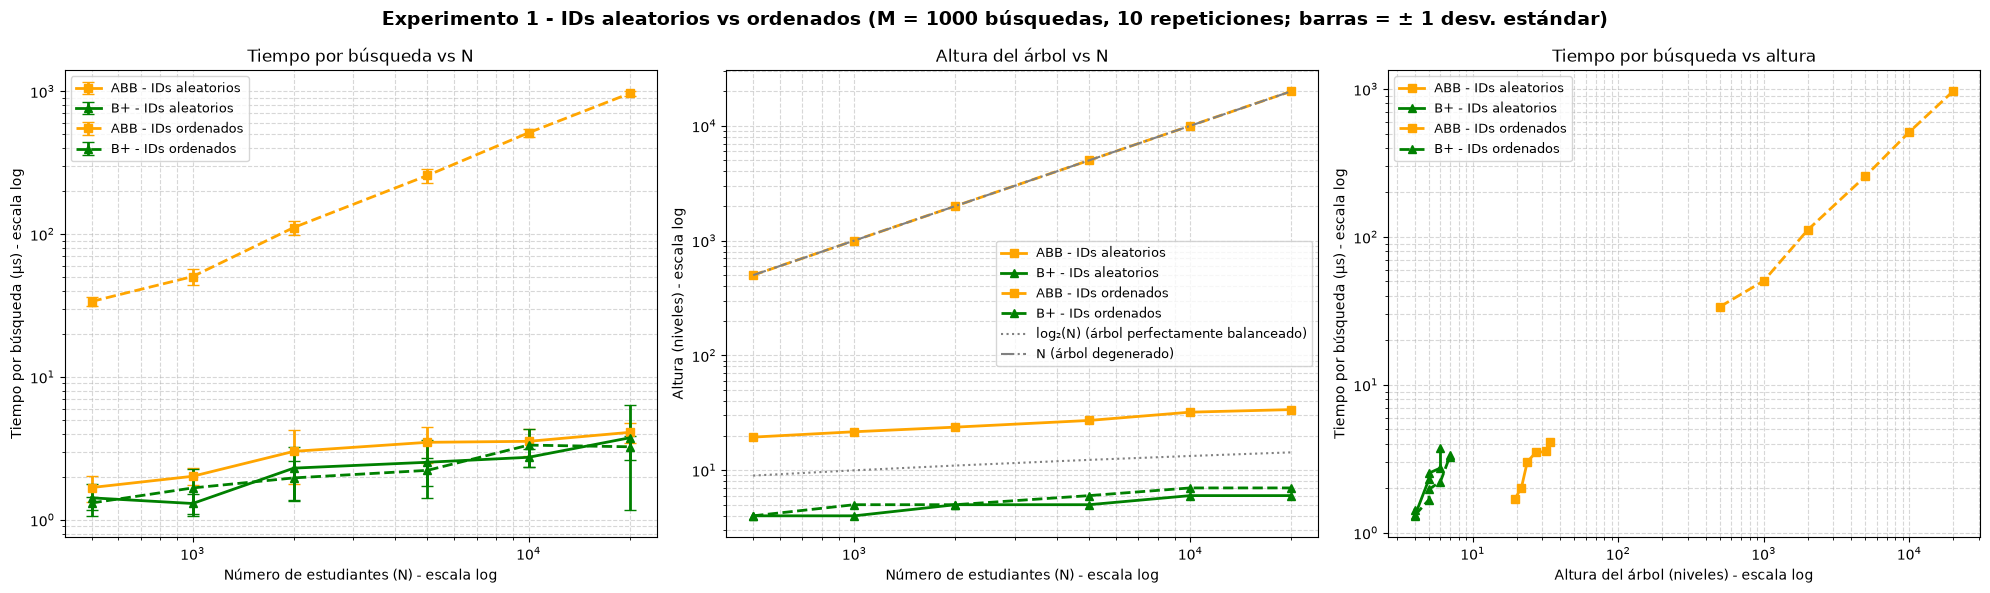

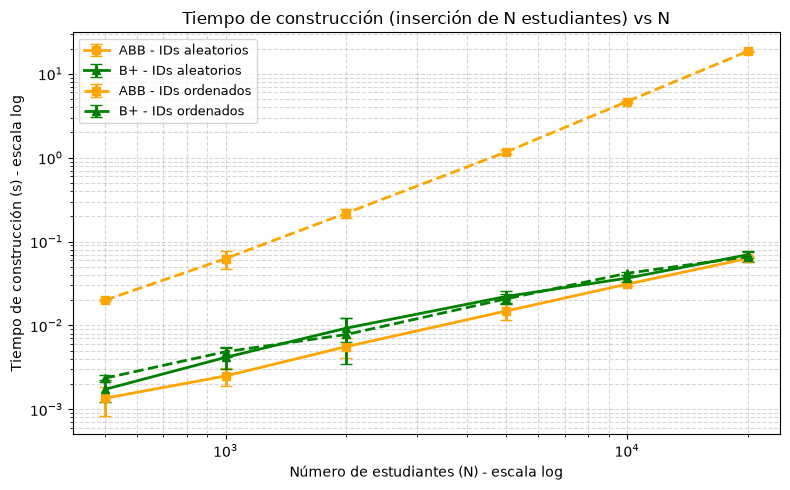

Media ± desv. estándar [mediana], en µs por búsqueda
         N |        ABB IDs aleatorios        |        B+ IDs aleatorios         |        ABB IDs ordenados         |         B+ IDs ordenados        
       500 |       1.681 ± 0.35 [1.733]       |       1.424 ± 0.36 [1.332]       |       33.73 ± 2.4 [33.64]        |       1.311 ± 0.14 [1.313]      
      1000 |       2.016 ± 0.27 [1.919]       |        1.3 ± 0.21 [1.344]        |       50.44 ± 6.2 [51.22]        |       1.671 ± 0.6 [1.785]       
      2000 |       3.013 ± 1.2 [2.839]        |       2.299 ± 0.92 [2.338]       |        111.2 ± 12 [109.5]        |       1.964 ± 0.61 [2.01]       
      5000 |       3.486 ± 0.97 [3.746]       |       2.527 ± 1.1 [2.097]        |        257.4 ± 29 [251.4]        |       2.218 ± 0.48 [2.087]      
     10000 |       3.542 ± 0.76 [3.625]       |       2.738 ± 0.38 [2.61]        |        512.1 ± 33 [517.4]        |       3.332 ± 0.98 [2.978]      
     20000 |       4.094 ± 0.64 [4.016]  

In [13]:
datos = datos_peor_caso
N = datos["N"]
nombres_caso = {"aleatorio": "aleatorios", "ordenado": "ordenados"}
linea_caso = {"aleatorio": "-", "ordenado": "--"}
estructuras = (("abb", "orange", "s", "ABB"), ("bplus", "green", "^", "B+"))

fig, ejes = plt.subplots(1, 3, figsize=(20, 6))
for caso in ("aleatorio", "ordenado"):
    for est, color, marcador, nombre in estructuras:
        etiqueta = f"{nombre} - IDs {nombres_caso[caso]}"
        medias = [r[est]["busqueda"]["media"] for r in datos[caso]]
        stds = [r[est]["busqueda"]["std"] for r in datos[caso]]
        alturas = [r[est]["altura"] for r in datos[caso]]
        ejes[0].errorbar(N, medias, yerr=stds, fmt=linea_caso[caso] + marcador, color=color,
                         label=etiqueta, capsize=4, linewidth=2)
        ejes[1].plot(N, alturas, linea_caso[caso] + marcador, color=color, label=etiqueta, linewidth=2)
        ejes[2].plot(alturas, medias, linea_caso[caso] + marcador, color=color, label=etiqueta, linewidth=2)

# Referencias teóricas para la altura
ejes[1].plot(N, np.log2(N), ":", color="gray", label="log₂(N) (árbol perfectamente balanceado)")
ejes[1].plot(N, N, "-.", color="gray", label="N (árbol degenerado)")

ejes[0].set_title("Tiempo por búsqueda vs N")
ejes[0].set_xlabel("Número de estudiantes (N) - escala log")
ejes[0].set_ylabel("Tiempo por búsqueda (µs) - escala log")
ejes[1].set_title("Altura del árbol vs N")
ejes[1].set_xlabel("Número de estudiantes (N) - escala log")
ejes[1].set_ylabel("Altura (niveles) - escala log")
ejes[2].set_title("Tiempo por búsqueda vs altura")
ejes[2].set_xlabel("Altura del árbol (niveles) - escala log")
ejes[2].set_ylabel("Tiempo por búsqueda (µs) - escala log")
for ax in ejes:
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(fontsize=9)
fig.suptitle(f"Experimento 1 - IDs aleatorios vs ordenados (M = {datos['M']} búsquedas, "
             f"{datos['repeticiones']} repeticiones; barras = ± 1 desv. estándar)", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_grafica("exp1_aleatorio_vs_ordenado")
plt.show()

# Tiempo de construcción
plt.figure(figsize=(8, 5))
for caso in ("aleatorio", "ordenado"):
    for est, color, marcador, nombre in estructuras:
        plt.errorbar(N, [r[est]["construccion"]["media"] for r in datos[caso]],
                     yerr=[r[est]["construccion"]["std"] for r in datos[caso]],
                     fmt=linea_caso[caso] + marcador, color=color, capsize=4, linewidth=2,
                     label=f"{nombre} - IDs {nombres_caso[caso]}")
plt.xscale("log"); plt.yscale("log")
plt.title("Tiempo de construcción (inserción de N estudiantes) vs N")
plt.xlabel("Número de estudiantes (N) - escala log")
plt.ylabel("Tiempo de construcción (s) - escala log")
plt.legend(fontsize=9)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
guardar_grafica("exp1_construccion_aleatorio_vs_ordenado")
plt.show()

# Tablas y exponentes empíricos
series = {f"{nombre} IDs {nombres_caso[caso]}": [r[est]["busqueda"] for r in datos[caso]]
          for caso in ("aleatorio", "ordenado") for est, _, _, nombre in estructuras}
imprimir_tabla("N", N, series, "µs por búsqueda")

print("Altura promedio de los árboles:")
for i, n in enumerate(N):
    print(f"  N = {n:6d} | ABB aleatorio {datos['aleatorio'][i]['abb']['altura']:6.1f} (log₂N = {math.log2(n):5.1f})"
          f" | ABB ordenado {datos['ordenado'][i]['abb']['altura']:6.1f}"
          f" | B+ aleatorio {datos['aleatorio'][i]['bplus']['altura']:.1f} | B+ ordenado {datos['ordenado'][i]['bplus']['altura']:.1f}")

print("\nExponente empírico (pendiente log-log de tiempo vs N; ~1 = lineal, ~2 = cuadrático, ~0 = casi constante):")
for caso in ("aleatorio", "ordenado"):
    for est, _, _, nombre in estructuras:
        t_busq = [r[est]["busqueda"]["media"] for r in datos[caso]]
        t_cons = [r[est]["construccion"]["media"] for r in datos[caso]]
        print(f"  {nombre:3s} IDs {caso:9s}: búsqueda ≈ N^{pendiente_loglog(N, t_busq):.2f} | construcción ≈ N^{pendiente_loglog(N, t_cons):.2f}")

# Relación altura - tiempo en el ABB (los dos casos juntos)
h_abb = [r["abb"]["altura"] for caso in ("aleatorio", "ordenado") for r in datos[caso]]
t_abb = [r["abb"]["busqueda"]["media"] for caso in ("aleatorio", "ordenado") for r in datos[caso]]
print(f"\nABB: R² de la regresión lineal tiempo ~ altura (ambos casos) = {r2(h_abb, t_abb):.3f}")

**Interpretación del Experimento 1:**

### Experimento 2: Escalabilidad de Busquedas

El objetivo de este experimento es evaluar la escalabilidad del tiempo de búsqueda de las tres estructuras (Lista Nativa, ABB y Árbol B+) a medida que el volumen de datos aumenta y contrastarla con la complejidad teórica.

Se varía el tamaño del conjunto de datos evaluando $N \in [10; 50; 100; 500; 1,000; 5,000; 10,000; 50,000; 100,000]$ estudiantes y se fija $M = 5,000$ búsquedas por repetición para todos los $N$ (si $M > N$ se muestrea con reemplazo, por lo que ya no se escalan los tiempos). En cada una de las 10 repeticiones por cada $N$ se genera un nuevo dataset con IDs aleatorios y se construyen las estructuras desde cero. Se reporta el tiempo por búsqueda en µs (tiempo del lote dividido entre $M$) con media, desviación estándar, mediana e IC del 95 %.

In [14]:
def benchmark_escalabilidad(tamanos, num_busquedas=5000, repeticiones=REPETICIONES, fallidas=False):
    resultados = {"N": tamanos, "M": num_busquedas, "repeticiones": repeticiones,
                  "lista": [], "abb": [], "bplus": []}
    tipo = "fallidas (IDs inexistentes)" if fallidas else "exitosas (IDs existentes)"

    print(f"--- INICIANDO EXPERIMENTACION ---")
    print(f"Búsquedas {tipo} por repetición (M): {num_busquedas} | Repeticiones por N: {repeticiones}")

    for n in tamanos:
        print(f"Evaluando N = {n} estudiantes...")
        tiempos = {"lista": [], "abb": [], "bplus": []}

        for _ in range(repeticiones):
            estudiantes = generar_dataset(n)
            lista, abb, bplus = construir_estructuras(estudiantes)
            ids = [est.Id for est in estudiantes]
            muestra_id = random.choices(ids, k=num_busquedas)
            if fallidas:
                muestra_id = [i + 0.5 for i in muestra_id]   # los IDs son enteros, así que x.5 nunca existe

            tiempos["lista"].append(medir_busqueda(lista, muestra_id))
            tiempos["abb"].append(medir_busqueda(abb, muestra_id))
            tiempos["bplus"].append(medir_busqueda(bplus, muestra_id))

        escala = 1e6 / num_busquedas   # segundos por lote -> µs por búsqueda
        for estructura in tiempos:
            resultados[estructura].append(resumen(tiempos[estructura], escala))

        for estructura, nombre in (("lista", "Lista"), ("abb", "ABB  "), ("bplus", "B+   ")):
            r = resultados[estructura][-1]
            print(f"  {nombre} -> Prom: {r['media']:.3f} µs (±{r['std']:.3f}) | mediana {r['mediana']:.3f} | atípicos {r['atipicos']}")
        print()

    return resultados

# Se incluyen N pequeños para visualizar el punto de inflexión (crossover)
tamanos_prueba = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]

datos_graficas = benchmark_escalabilidad(tamanos_prueba)

--- INICIANDO EXPERIMENTACION ---
Búsquedas exitosas (IDs existentes) por repetición (M): 5000 | Repeticiones por N: 10
Evaluando N = 10 estudiantes...
  Lista -> Prom: 0.498 µs (±0.084) | mediana 0.507 | atípicos 2
  ABB   -> Prom: 0.637 µs (±0.095) | mediana 0.635 | atípicos 0
  B+    -> Prom: 0.743 µs (±0.149) | mediana 0.726 | atípicos 2

Evaluando N = 50 estudiantes...
  Lista -> Prom: 1.678 µs (±0.266) | mediana 1.741 | atípicos 1
  ABB   -> Prom: 1.114 µs (±0.117) | mediana 1.106 | atípicos 1
  B+    -> Prom: 1.021 µs (±0.093) | mediana 1.029 | atípicos 0

Evaluando N = 100 estudiantes...
  Lista -> Prom: 3.183 µs (±0.254) | mediana 3.151 | atípicos 2
  ABB   -> Prom: 1.261 µs (±0.221) | mediana 1.323 | atípicos 1
  B+    -> Prom: 1.001 µs (±0.088) | mediana 1.008 | atípicos 0

Evaluando N = 500 estudiantes...
  Lista -> Prom: 11.282 µs (±1.616) | mediana 11.421 | atípicos 0
  ABB   -> Prom: 1.721 µs (±0.308) | mediana 1.687 | atípicos 4
  B+    -> Prom: 1.221 µs (±0.159) | medi

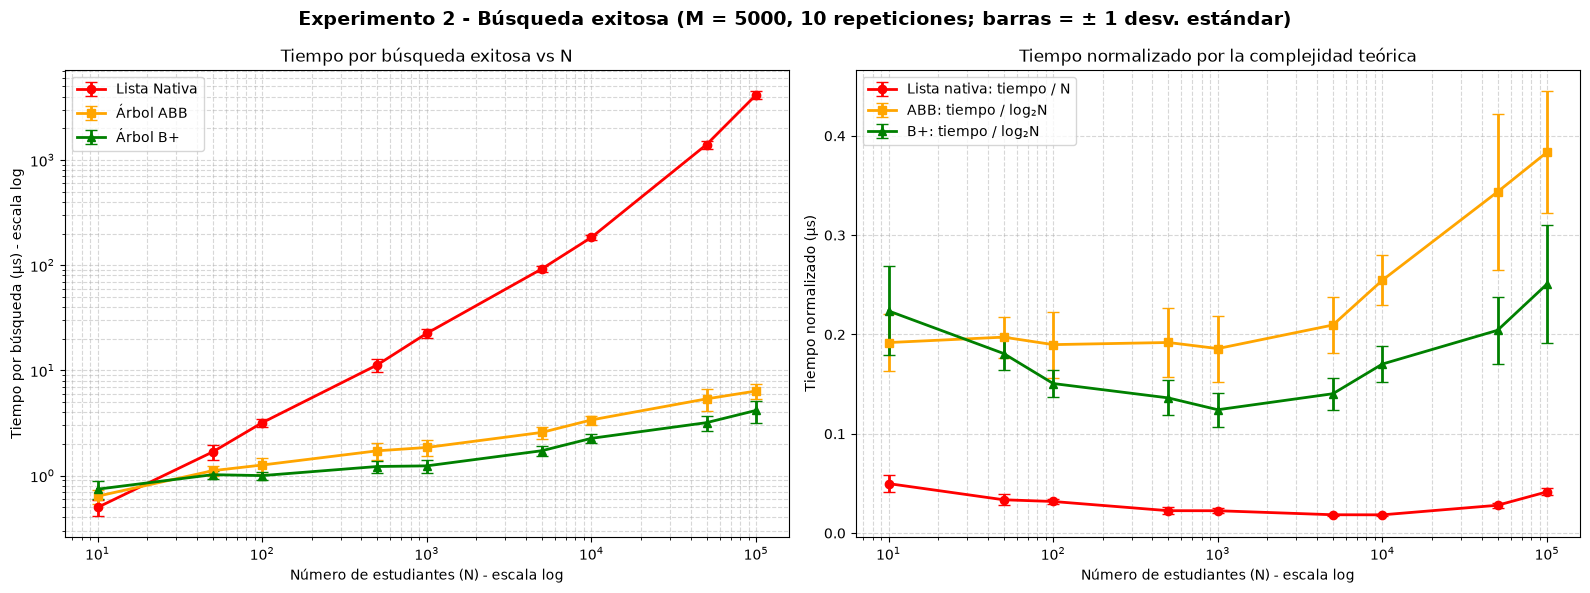

Media ± desv. estándar [mediana], en µs por búsqueda
         N |              Lista               |               ABB                |                B+               
        10 |     0.4984 ± 0.084 [0.5069]      |     0.6373 ± 0.095 [0.6352]      |      0.7431 ± 0.15 [0.7265]     
        50 |       1.678 ± 0.27 [1.741]       |       1.114 ± 0.12 [1.106]       |      1.021 ± 0.093 [1.029]      
       100 |       3.183 ± 0.25 [3.151]       |       1.261 ± 0.22 [1.323]       |      1.001 ± 0.088 [1.008]      
       500 |       11.28 ± 1.6 [11.42]        |       1.721 ± 0.31 [1.687]       |       1.221 ± 0.16 [1.246]      
      1000 |       22.53 ± 2.3 [22.42]        |       1.852 ± 0.33 [1.948]       |       1.238 ± 0.17 [1.237]      
      5000 |         92.36 ± 5.4 [92]         |       2.574 ± 0.35 [2.665]       |        1.724 ± 0.2 [1.74]       
     10000 |       183.9 ± 8.9 [185.4]        |       3.384 ± 0.34 [3.249]       |       2.262 ± 0.24 [2.296]      
     50000 |      1

In [15]:
def graficar_escalabilidad(datos, tipo, archivo):
    n_vals = np.array(datos["N"], dtype=float)
    fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: tiempo por búsqueda (media ± desviación estándar)
    graficar_series(ejes[0], n_vals, datos)
    ejes[0].set_xscale("log")
    ejes[0].set_yscale("log")
    ejes[0].set_title(f"Tiempo por búsqueda {tipo} vs N")
    ejes[0].set_xlabel("Número de estudiantes (N) - escala log")
    ejes[0].set_ylabel("Tiempo por búsqueda (µs) - escala log")

    # Panel 2: tiempo normalizado por la complejidad teórica (debería ser ~constante)
    normalizacion = {"lista": (n_vals, "Lista nativa: tiempo / N"),
                     "abb": (np.log2(n_vals), "ABB: tiempo / log₂N"),
                     "bplus": (np.log2(n_vals), "B+: tiempo / log₂N")}
    for k, (divisor, etiqueta) in normalizacion.items():
        color, marcador, _ = ESTILOS[k]
        medias = np.array([r["media"] for r in datos[k]]) / divisor
        stds = np.array([r["std"] for r in datos[k]]) / divisor
        ejes[1].errorbar(n_vals, medias, yerr=stds, fmt="-" + marcador, color=color,
                         label=etiqueta, capsize=4, linewidth=2)
    ejes[1].set_xscale("log")
    ejes[1].set_title("Tiempo normalizado por la complejidad teórica")
    ejes[1].set_xlabel("Número de estudiantes (N) - escala log")
    ejes[1].set_ylabel("Tiempo normalizado (µs)")

    for ax in ejes:
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.legend(fontsize=10)
    fig.suptitle(f"Experimento 2 - Búsqueda {tipo} (M = {datos['M']}, {datos['repeticiones']} repeticiones; barras = ± 1 desv. estándar)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    guardar_grafica(archivo)
    plt.show()

def punto_cruce(datos, lento, rapido):
    """Menor N desde el cual 'lento' es significativamente más lento que 'rapido'
    (IC 95 % sin traslape) para ese N y para todos los N mayores."""
    cruce = None
    for i in range(len(datos["N"]) - 1, -1, -1):
        a, b = datos[lento][i], datos[rapido][i]
        if a["media"] - a["ic95"] > b["media"] + b["ic95"]:
            cruce = datos["N"][i]
        else:
            break
    return cruce

def analizar_escalabilidad(datos, n_min=100):
    N = np.array(datos["N"], dtype=float)
    usar = N >= n_min   # los N muy pequeños están dominados por costos fijos y se excluyen de los ajustes
    imprimir_tabla("N", datos["N"], {"Lista": datos["lista"], "ABB": datos["abb"], "B+": datos["bplus"]}, "µs por búsqueda")

    print(f"Ajustes sobre la media, solo con N >= {n_min}:")
    for k, nombre in (("lista", "Lista"), ("abb", "ABB"), ("bplus", "B+")):
        y = np.array([r["media"] for r in datos[k]])
        print(f"  {nombre:5s} exponente log-log = {pendiente_loglog(N[usar], y[usar]):5.2f}"
              f" | R² (tiempo ~ N) = {r2(N[usar], y[usar]):.3f}"
              f" | R² (tiempo ~ log₂N) = {r2(np.log2(N[usar]), y[usar]):.3f}")

    print("\nPrimer N desde el cual la diferencia es significativa (IC 95 % sin traslape):")
    for lento, rapido, texto in (("lista", "abb", "Lista más lenta que ABB"),
                                 ("lista", "bplus", "Lista más lenta que B+"),
                                 ("abb", "bplus", "ABB más lento que B+")):
        c = punto_cruce(datos, lento, rapido)
        print(f"  {texto}: " + (f"N >= {c}" if c is not None else "no hay diferencia significativa sostenida"))

graficar_escalabilidad(datos_graficas, "exitosa", "exp2_escalabilidad_busqueda_exitosa")
analizar_escalabilidad(datos_graficas)

### Experimento 2b: Búsquedas fallidas

El objetivo es comparar el costo de buscar IDs que **no existen**. En la lista nativa una búsqueda fallida siempre recorre los $N$ elementos (el peor caso), mientras que en una exitosa recorre en promedio $N/2$. Para generar IDs inexistentes se buscan los IDs del muestreo sumándoles 0.5: como los IDs son enteros, `id + 0.5` nunca existe y la comparación funciona igual en las tres estructuras.

Se repite exactamente el diseño del Experimento 2 (mismos $N$, mismo $M$, 10 repeticiones).

--- INICIANDO EXPERIMENTACION ---
Búsquedas fallidas (IDs inexistentes) por repetición (M): 5000 | Repeticiones por N: 10
Evaluando N = 10 estudiantes...
  Lista -> Prom: 1.254 µs (±0.354) | mediana 1.152 | atípicos 1
  ABB   -> Prom: 1.219 µs (±0.135) | mediana 1.195 | atípicos 0
  B+    -> Prom: 0.958 µs (±0.201) | mediana 1.046 | atípicos 1

Evaluando N = 50 estudiantes...
  Lista -> Prom: 4.660 µs (±0.274) | mediana 4.564 | atípicos 1
  ABB   -> Prom: 2.032 µs (±0.504) | mediana 2.048 | atípicos 3
  B+    -> Prom: 1.272 µs (±0.193) | mediana 1.231 | atípicos 0

Evaluando N = 100 estudiantes...
  Lista -> Prom: 7.287 µs (±1.342) | mediana 7.797 | atípicos 1
  ABB   -> Prom: 2.393 µs (±0.842) | mediana 2.161 | atípicos 3
  B+    -> Prom: 1.377 µs (±0.172) | mediana 1.312 | atípicos 1

Evaluando N = 500 estudiantes...
  Lista -> Prom: 29.697 µs (±2.592) | mediana 29.258 | atípicos 0
  ABB   -> Prom: 2.993 µs (±0.336) | mediana 2.931 | atípicos 0
  B+    -> Prom: 1.692 µs (±0.127) | me

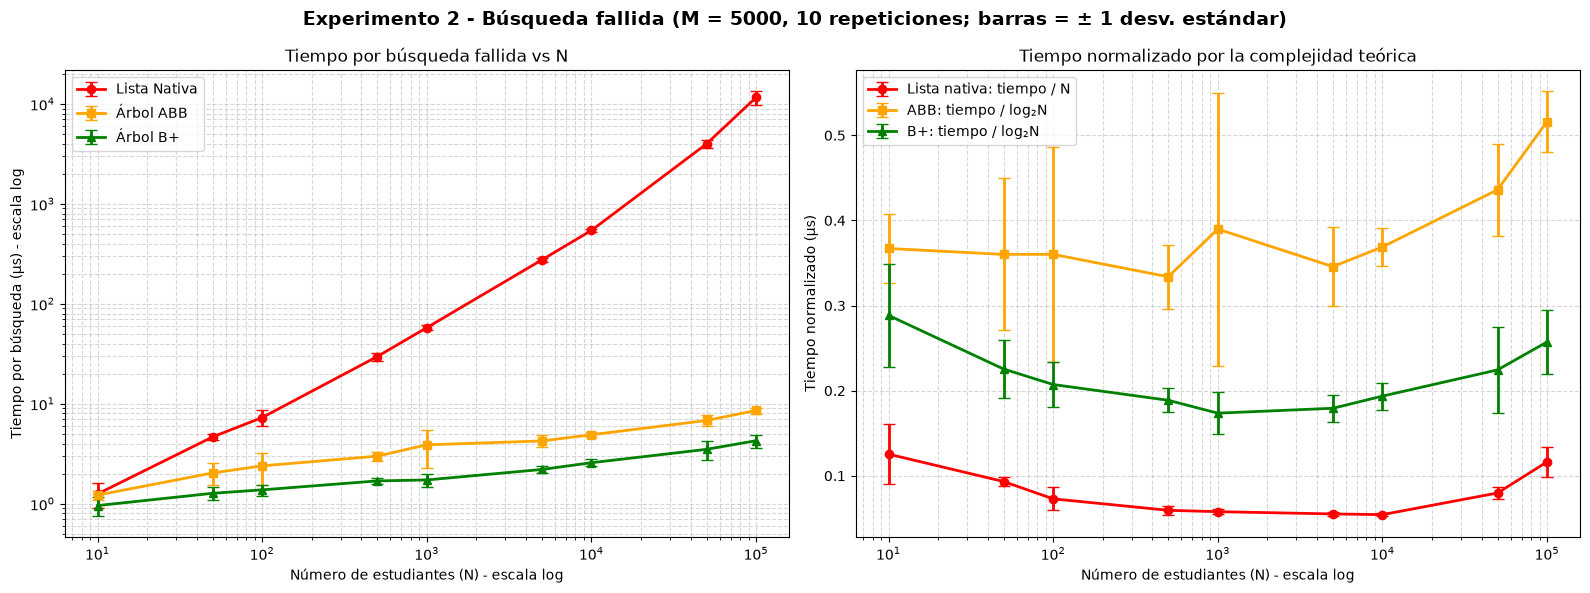

Media ± desv. estándar [mediana], en µs por búsqueda
         N |              Lista               |               ABB                |                B+               
        10 |       1.254 ± 0.35 [1.152]       |       1.219 ± 0.14 [1.195]       |       0.9583 ± 0.2 [1.046]      
        50 |       4.66 ± 0.27 [4.564]        |       2.032 ± 0.5 [2.048]        |       1.272 ± 0.19 [1.231]      
       100 |       7.287 ± 1.3 [7.797]        |       2.393 ± 0.84 [2.161]       |       1.377 ± 0.17 [1.312]      
       500 |        29.7 ± 2.6 [29.26]        |       2.993 ± 0.34 [2.931]       |       1.692 ± 0.13 [1.693]      
      1000 |        57.8 ± 3.3 [58.55]        |       3.885 ± 1.6 [3.349]        |       1.73 ± 0.25 [1.807]       
      5000 |        275.6 ± 11 [274.8]        |       4.248 ± 0.57 [4.244]       |       2.203 ± 0.19 [2.166]      
     10000 |        543.2 ± 14 [540.9]        |       4.902 ± 0.3 [4.894]        |       2.572 ± 0.21 [2.533]      
     50000 |      3

In [16]:
datos_fallidas = benchmark_escalabilidad(tamanos_prueba, fallidas=True)
graficar_escalabilidad(datos_fallidas, "fallida", "exp2b_escalabilidad_busqueda_fallida")
analizar_escalabilidad(datos_fallidas)

# Comparación directa exitosa vs fallida para la lista (debería ser ~2x si recorre N en vez de N/2)
print("Razón fallida / exitosa en la lista nativa:")
for i, n in enumerate(datos_graficas["N"]):
    print(f"  N = {n:6d}: {datos_fallidas['lista'][i]['media'] / datos_graficas['lista'][i]['media']:.2f}")

### Experimento 3: Costo Computacional de la Construcción de Estructuras

El objetivo de este experimento es analizar el coste temporal de construcción (inserción masiva) de cada estructura desde cero, para evidenciar el esfuerzo algorítmico necesario para poblar los sistemas a medida que la cantidad de datos crece.

Se varía la cantidad de datos de entrada de $N \in [1,000; 5,000; 10,000; 20,000; 50,000]$. En cada repetición (10 por cada $N$) se genera un dataset nuevo con IDs aleatorios para evitar sesgos por una única distribución inicial. Se mide el tiempo de insertar todos los estudiantes en cada estructura completamente vacía, reportando media y desviación estándar. 

In [17]:
def benchmark_construccion(tamanos=[1000, 5000, 10000, 20000, 50000], repeticiones=REPETICIONES):
    print(f"--- EXPERIMENTO: TIEMPO DE CONSTRUCCIÓN VS TAMAÑO (N) ---")
    resultados = {"N": tamanos, "repeticiones": repeticiones, "lista": [], "abb": [], "bplus": []}

    for n in tamanos:
        print(f"Evaluando construcción con {n} estudiantes...")
        tiempos = {"lista": [], "abb": [], "bplus": []}

        for _ in range(repeticiones):
            # Generar dataset fresco para evitar sesgos
            estudiantes = generar_dataset(n)

            # Instanciar fuera de la medición
            lista = ListaEstudiantes()
            abb = ABB()
            bplus = BplusTree(order=8)

            tiempos["lista"].append(cronometrar(insertar_todos, lista, estudiantes))
            tiempos["abb"].append(cronometrar(insertar_todos, abb, estudiantes))
            tiempos["bplus"].append(cronometrar(insertar_todos, bplus, estudiantes))

        for estructura in tiempos:
            resultados[estructura].append(resumen(tiempos[estructura]))

        for estructura, nombre in (("lista", "Lista"), ("abb", "ABB  "), ("bplus", "B+   ")):
            r = resultados[estructura][-1]
            print(f"  {nombre} -> Prom: {r['media']:.4f}s (±{r['std']:.4f}s) | mediana {r['mediana']:.4f}s | atípicos {r['atipicos']}")
        print()

    return resultados

datos_construccion = benchmark_construccion()

--- EXPERIMENTO: TIEMPO DE CONSTRUCCIÓN VS TAMAÑO (N) ---
Evaluando construcción con 1000 estudiantes...
  Lista -> Prom: 0.0002s (±0.0000s) | mediana 0.0002s | atípicos 1
  ABB   -> Prom: 0.0026s (±0.0005s) | mediana 0.0026s | atípicos 1
  B+    -> Prom: 0.0041s (±0.0010s) | mediana 0.0042s | atípicos 0

Evaluando construcción con 5000 estudiantes...
  Lista -> Prom: 0.0011s (±0.0003s) | mediana 0.0011s | atípicos 0
  ABB   -> Prom: 0.0191s (±0.0037s) | mediana 0.0192s | atípicos 0
  B+    -> Prom: 0.0182s (±0.0043s) | mediana 0.0188s | atípicos 0

Evaluando construcción con 10000 estudiantes...
  Lista -> Prom: 0.0017s (±0.0004s) | mediana 0.0016s | atípicos 0
  ABB   -> Prom: 0.0344s (±0.0052s) | mediana 0.0334s | atípicos 0
  B+    -> Prom: 0.0381s (±0.0085s) | mediana 0.0383s | atípicos 1

Evaluando construcción con 20000 estudiantes...
  Lista -> Prom: 0.0027s (±0.0004s) | mediana 0.0026s | atípicos 1
  ABB   -> Prom: 0.0637s (±0.0051s) | mediana 0.0654s | atípicos 1
  B+    -> P

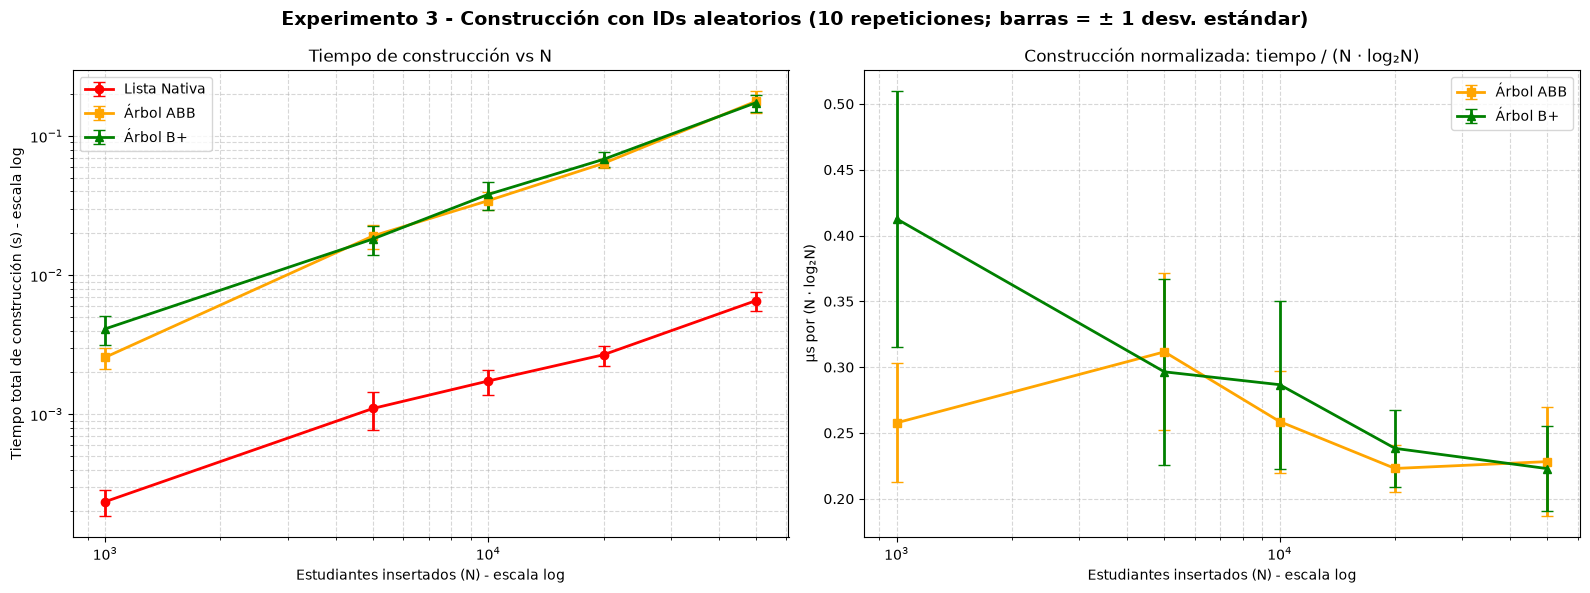

Media ± desv. estándar [mediana], en s (construcción completa)
         N |              Lista               |               ABB                |                B+               
      1000 | 0.0002352 ± 4.9e-05 [0.0002245]  |  0.002568 ± 0.00045 [0.002551]   |  0.004112 ± 0.00097 [0.004192]  
      5000 |  0.001101 ± 0.00033 [0.001103]   |    0.01914 ± 0.0037 [0.01924]    |    0.01821 ± 0.0043 [0.01882]   
     10000 |  0.001735 ± 0.00036 [0.001645]   |    0.03437 ± 0.0052 [0.03343]    |    0.03809 ± 0.0085 [0.03832]   
     20000 |   0.00268 ± 0.00044 [0.002647]   |    0.06373 ± 0.0051 [0.06538]    |    0.06809 ± 0.0084 [0.07131]   
     50000 |   0.006566 ± 0.0011 [0.006731]   |     0.1781 ± 0.032 [0.1725]      |      0.174 ± 0.025 [0.1684]     

  Lista exponente log-log (tiempo vs N) = 0.83
  ABB   exponente log-log (tiempo vs N) = 1.07
  B+    exponente log-log (tiempo vs N) = 0.96


In [18]:
datos = datos_construccion
N = np.array(datos["N"], dtype=float)
fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

graficar_series(ejes[0], N, datos)
ejes[0].set_xscale("log")
ejes[0].set_yscale("log")
ejes[0].set_title("Tiempo de construcción vs N")
ejes[0].set_xlabel("Estudiantes insertados (N) - escala log")
ejes[0].set_ylabel("Tiempo total de construcción (s) - escala log")

# Normalización t / (N log2 N): constante si la construcción de los árboles es O(N log N)
factor = 1e6 / (N * np.log2(N))
for k in ("abb", "bplus"):
    color, marcador, etiqueta = ESTILOS[k]
    medias = np.array([r["media"] for r in datos[k]]) * factor
    stds = np.array([r["std"] for r in datos[k]]) * factor
    ejes[1].errorbar(N, medias, yerr=stds, fmt="-" + marcador, color=color, label=etiqueta, capsize=4, linewidth=2)
ejes[1].set_xscale("log")
ejes[1].set_title("Construcción normalizada: tiempo / (N · log₂N)")
ejes[1].set_xlabel("Estudiantes insertados (N) - escala log")
ejes[1].set_ylabel("µs por (N · log₂N)")

for ax in ejes:
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(fontsize=10)
fig.suptitle(f"Experimento 3 - Construcción con IDs aleatorios ({datos['repeticiones']} repeticiones; barras = ± 1 desv. estándar)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_grafica("exp3_construccion")
plt.show()

imprimir_tabla("N", datos["N"], {"Lista": datos["lista"], "ABB": datos["abb"], "B+": datos["bplus"]}, "s (construcción completa)")
for k, nombre in (("lista", "Lista"), ("abb", "ABB"), ("bplus", "B+")):
    y = [r["media"] for r in datos[k]]
    print(f"  {nombre:5s} exponente log-log (tiempo vs N) = {pendiente_loglog(datos['N'], y):.2f}")

### Experimento 4: Costo de Busqueda

El objetivo de este experimento es evaluar el impacto de la cantidad de consultas en el tiempo de ejecución de las tres estructuras (Lista Nativa, ABB y Árbol B+), manteniendo la cantidad total de registros constante. Sirve para confirmar que el tiempo total es proporcional a $M$, es decir, que el costo **por búsqueda** no depende del número de búsquedas.

Se fija el tamaño del conjunto de datos en $N = 50,000$ estudiantes. Se varía el tamaño del lote de búsquedas, ejecutando volúmenes de $M \in [1,000; 5,000; 10,000; 20,000; 50,000]$ operaciones, con 5 repeticiones por cada lote (menos que en los demás experimentos porque la lista a $M = 50,000$ tarda más de un minuto por repetición) utilizando IDs seleccionados de forma aleatoria. Se construyen las estructuras una sola vez y lo que varía entre repeticiones es la muestra de IDs buscados.

In [19]:
def benchmark_cantidad_busquedas(n_constante=50000, lotes_busquedas=[1000, 5000, 10000, 20000, 50000], repeticiones=5):
    print(f"--- EXPERIMENTO: TIEMPO VS # DE BÚSQUEDAS (N Constante = {n_constante}) ---")

    # Preparar el dataset único para todas las pruebas de esta celda
    estudiantes = generar_dataset(n_constante)
    lista, abb, bplus = construir_estructuras(estudiantes)
    ids_totales = [est.Id for est in estudiantes]

    resultados = {"B": lotes_busquedas, "N": n_constante, "repeticiones": repeticiones,
                  "lista": [], "abb": [], "bplus": []}

    for b in lotes_busquedas:
        print(f"Evaluando {b} búsquedas...")
        tiempos = {"lista": [], "abb": [], "bplus": []}

        for _ in range(repeticiones):
            muestra_id = random.choices(ids_totales, k=b)
            tiempos["lista"].append(medir_busqueda(lista, muestra_id))
            tiempos["abb"].append(medir_busqueda(abb, muestra_id))
            tiempos["bplus"].append(medir_busqueda(bplus, muestra_id))

        for estructura in tiempos:
            resultados[estructura].append(resumen(tiempos[estructura]))

        for estructura, nombre in (("lista", "Lista"), ("abb", "ABB  "), ("bplus", "B+   ")):
            r = resultados[estructura][-1]
            print(f"  {nombre} -> Prom: {r['media']:.4f}s (±{r['std']:.4f}s)")
        print()

    return resultados

datos_busquedas = benchmark_cantidad_busquedas()

--- EXPERIMENTO: TIEMPO VS # DE BÚSQUEDAS (N Constante = 50000) ---
Evaluando 1000 búsquedas...
  Lista -> Prom: 1.5203s (±0.2251s)
  ABB   -> Prom: 0.0051s (±0.0003s)
  B+    -> Prom: 0.0032s (±0.0007s)

Evaluando 5000 búsquedas...
  Lista -> Prom: 8.2157s (±0.6211s)
  ABB   -> Prom: 0.0287s (±0.0050s)
  B+    -> Prom: 0.0144s (±0.0034s)

Evaluando 10000 búsquedas...
  Lista -> Prom: 13.6679s (±0.3077s)
  ABB   -> Prom: 0.0435s (±0.0022s)
  B+    -> Prom: 0.0256s (±0.0015s)

Evaluando 20000 búsquedas...
  Lista -> Prom: 26.4599s (±1.0546s)
  ABB   -> Prom: 0.0775s (±0.0018s)
  B+    -> Prom: 0.0453s (±0.0017s)

Evaluando 50000 búsquedas...
  Lista -> Prom: 69.5319s (±2.3195s)
  ABB   -> Prom: 0.1904s (±0.0103s)
  B+    -> Prom: 0.1106s (±0.0124s)



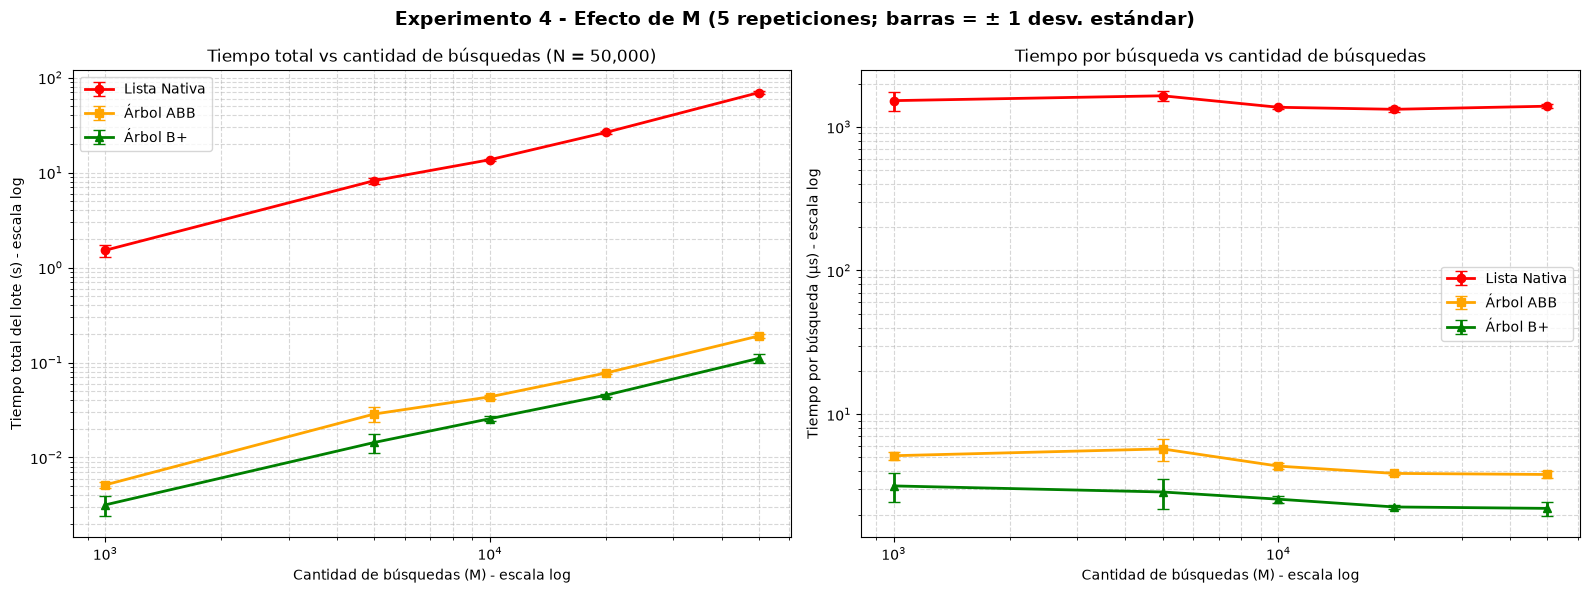

Media ± desv. estándar [mediana], en s (lote completo)
         M |              Lista               |               ABB                |                B+               
      1000 |       1.52 ± 0.23 [1.432]        |  0.005144 ± 0.00032 [0.005185]   |   0.00317 ± 0.00074 [0.00338]   
      5000 |       8.216 ± 0.62 [8.286]       |    0.02867 ± 0.005 [0.02769]     |    0.01438 ± 0.0034 [0.01406]   
     10000 |       13.67 ± 0.31 [13.7]        |    0.04354 ± 0.0022 [0.04289]    |    0.02563 ± 0.0015 [0.02495]   
     20000 |       26.46 ± 1.1 [27.07]        |    0.07747 ± 0.0018 [0.07752]    |    0.04526 ± 0.0017 [0.04498]   
     50000 |       69.53 ± 2.3 [70.22]        |      0.1904 ± 0.01 [0.189]       |     0.1106 ± 0.012 [0.1087]     

  Lista exponente log-log (tiempo vs M) = 0.96  (1.00 = proporcional a M)
  ABB   exponente log-log (tiempo vs M) = 0.90  (1.00 = proporcional a M)
  B+    exponente log-log (tiempo vs M) = 0.90  (1.00 = proporcional a M)


In [20]:
datos = datos_busquedas
B = np.array(datos["B"], dtype=float)
fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

graficar_series(ejes[0], B, datos)
ejes[0].set_xscale("log")
ejes[0].set_yscale("log")
ejes[0].set_title(f"Tiempo total vs cantidad de búsquedas (N = {datos['N']:,})")
ejes[0].set_xlabel("Cantidad de búsquedas (M) - escala log")
ejes[0].set_ylabel("Tiempo total del lote (s) - escala log")

# Costo por búsqueda: debería ser constante si el tiempo total es lineal en M
for k in ("lista", "abb", "bplus"):
    color, marcador, etiqueta = ESTILOS[k]
    medias = np.array([r["media"] for r in datos[k]]) * 1e6 / B
    stds = np.array([r["std"] for r in datos[k]]) * 1e6 / B
    ejes[1].errorbar(B, medias, yerr=stds, fmt="-" + marcador, color=color, label=etiqueta, capsize=4, linewidth=2)
ejes[1].set_xscale("log")
ejes[1].set_yscale("log")
ejes[1].set_title("Tiempo por búsqueda vs cantidad de búsquedas")
ejes[1].set_xlabel("Cantidad de búsquedas (M) - escala log")
ejes[1].set_ylabel("Tiempo por búsqueda (µs) - escala log")

for ax in ejes:
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(fontsize=10)
fig.suptitle(f"Experimento 4 - Efecto de M ({datos['repeticiones']} repeticiones; barras = ± 1 desv. estándar)", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_grafica("exp4_cantidad_busquedas")
plt.show()

imprimir_tabla("M", datos["B"], {"Lista": datos["lista"], "ABB": datos["abb"], "B+": datos["bplus"]}, "s (lote completo)")
for k, nombre in (("lista", "Lista"), ("abb", "ABB"), ("bplus", "B+")):
    y = [r["media"] for r in datos[k]]
    print(f"  {nombre:5s} exponente log-log (tiempo vs M) = {pendiente_loglog(datos['B'], y):.2f}  (1.00 = proporcional a M)")

### Experimento 5: Busquedas por Rangos

El objetivo de este experimento es analizar el rendimiento de las estructuras al ejecutar búsquedas por rangos. En particular, se busca validar la ventaja teórica de los punteros a nivel de hoja en el Árbol B+ durante la extracción masiva y secuencial. Este experimento es un complemento: el enunciado no pide búsqueda por rango.

Empleando una población constante de $N = 50,000$ estudiantes, se varía la amplitud del rango de $A \in [100; 500; 1,000; 5,000; 10,000]$ elementos consecutivos, con 10 repeticiones y un punto de inicio aleatorio en cada una, reportando media y desviación estándar. En cada repetición se comprueba que las tres estructuras devuelven la misma cantidad de elementos.

In [21]:
def benchmark_rangos(n_constante=50000, amplitud_rangos=[100, 500, 1000, 5000, 10000], repeticiones=REPETICIONES):
    print(f"--- EXPERIMENTO: BÚSQUEDA POR RANGO (N Constante = {n_constante}) ---")

    estudiantes = generar_dataset(n_constante)
    lista, abb, bplus = construir_estructuras(estudiantes)
    ids_totales = sorted([est.Id for est in estudiantes])

    resultados = {"Rango": amplitud_rangos, "N": n_constante, "repeticiones": repeticiones,
                  "lista": [], "abb": [], "bplus": []}

    for amplitud in amplitud_rangos:
        print(f"Evaluando extracción de rango de tamaño {amplitud}...")
        tiempos = {"lista": [], "abb": [], "bplus": []}

        for _ in range(repeticiones):
            # Seleccionar un punto de inicio aleatorio asegurando que el rango exista
            idx_inicio = random.randint(0, len(ids_totales) - amplitud - 1)
            id_i = ids_totales[idx_inicio]
            id_f = ids_totales[idx_inicio + amplitud]

            # Las tres estructuras deben devolver la misma cantidad de elementos
            assert len(lista.buscar_rango(id_i, id_f)) == len(abb.buscar_rango(id_i, id_f)) == len(bplus.buscar_rango(id_i, id_f))

            tiempos["lista"].append(cronometrar(lista.buscar_rango, id_i, id_f))
            tiempos["abb"].append(cronometrar(abb.buscar_rango, id_i, id_f))
            tiempos["bplus"].append(cronometrar(bplus.buscar_rango, id_i, id_f))

        for estructura in tiempos:
            resultados[estructura].append(resumen(tiempos[estructura], 1e3))   # s -> ms

        for estructura, nombre in (("lista", "Lista"), ("abb", "ABB  "), ("bplus", "B+   ")):
            r = resultados[estructura][-1]
            print(f"  {nombre} -> Prom: {r['media']:.4f} ms (±{r['std']:.4f} ms)")
        print()

    return resultados

datos_rangos = benchmark_rangos()

--- EXPERIMENTO: BÚSQUEDA POR RANGO (N Constante = 50000) ---
Evaluando extracción de rango de tamaño 100...
  Lista -> Prom: 10.0081 ms (±1.7510 ms)
  ABB   -> Prom: 0.1366 ms (±0.0379 ms)
  B+    -> Prom: 0.1135 ms (±0.0232 ms)

Evaluando extracción de rango de tamaño 500...
  Lista -> Prom: 10.6328 ms (±2.3072 ms)
  ABB   -> Prom: 0.4566 ms (±0.0592 ms)
  B+    -> Prom: 0.3382 ms (±0.0760 ms)

Evaluando extracción de rango de tamaño 1000...
  Lista -> Prom: 10.9263 ms (±2.4085 ms)
  ABB   -> Prom: 1.0546 ms (±0.2937 ms)
  B+    -> Prom: 0.7906 ms (±0.2606 ms)

Evaluando extracción de rango de tamaño 5000...
  Lista -> Prom: 10.1887 ms (±3.3652 ms)
  ABB   -> Prom: 3.4695 ms (±0.4830 ms)
  B+    -> Prom: 2.9554 ms (±0.7545 ms)

Evaluando extracción de rango de tamaño 10000...
  Lista -> Prom: 11.5659 ms (±1.2383 ms)
  ABB   -> Prom: 7.0692 ms (±0.6110 ms)
  B+    -> Prom: 4.8929 ms (±0.9110 ms)



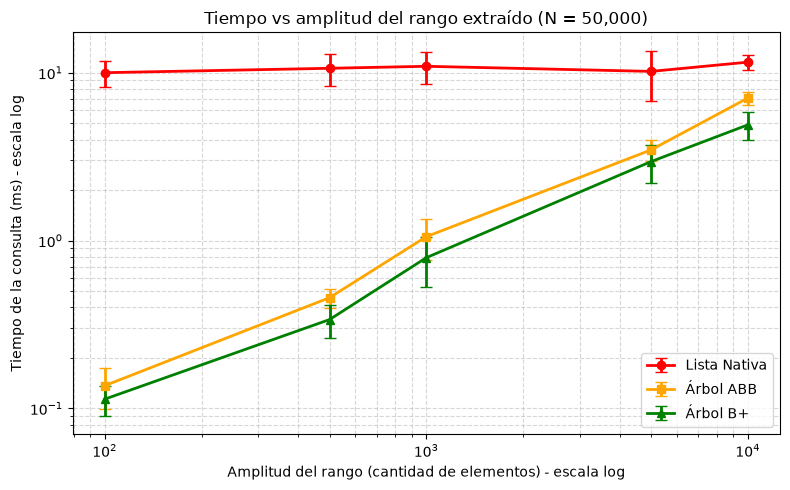

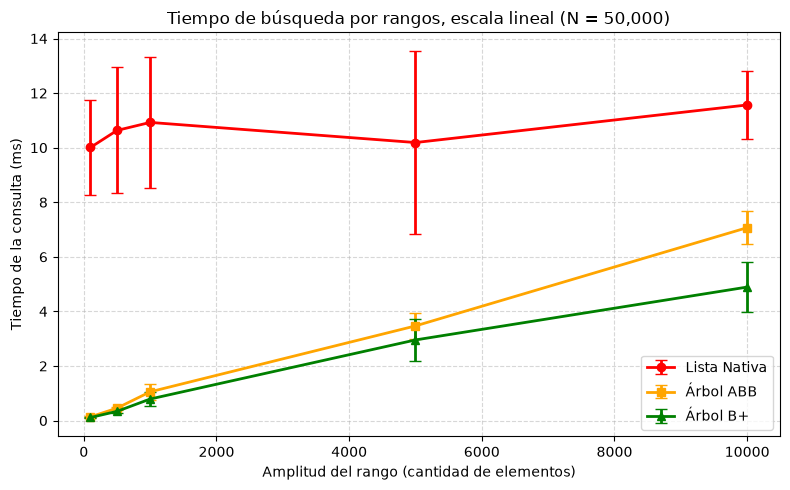

Media ± desv. estándar [mediana], en ms
  Amplitud |              Lista               |               ABB                |                B+               
       100 |       10.01 ± 1.8 [10.15]        |     0.1366 ± 0.038 [0.1448]      |      0.1135 ± 0.023 [0.104]     
       500 |       10.63 ± 2.3 [10.88]        |     0.4566 ± 0.059 [0.4393]      |     0.3382 ± 0.076 [0.3031]     
      1000 |       10.93 ± 2.4 [11.75]        |      1.055 ± 0.29 [0.9552]       |      0.7906 ± 0.26 [0.7169]     
      5000 |       10.19 ± 3.4 [10.87]        |       3.47 ± 0.48 [3.419]        |       2.955 ± 0.75 [2.939]      
     10000 |       11.57 ± 1.2 [11.76]        |       7.069 ± 0.61 [7.088]       |       4.893 ± 0.91 [5.099]      



In [22]:
datos = datos_rangos
A = datos["Rango"]

# Gráfica en escala logarítmica
plt.figure(figsize=(8, 5))
graficar_series(plt.gca(), A, datos)
plt.xscale("log")
plt.yscale("log")
plt.title(f"Tiempo vs amplitud del rango extraído (N = {datos['N']:,})")
plt.xlabel("Amplitud del rango (cantidad de elementos) - escala log")
plt.ylabel("Tiempo de la consulta (ms) - escala log")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
guardar_grafica("exp5_rangos_log")
plt.show()

# Gráfica (Escala Lineal para observar el cruce de curvas)
plt.figure(figsize=(8, 5))
graficar_series(plt.gca(), A, datos)
plt.title(f"Tiempo de búsqueda por rangos, escala lineal (N = {datos['N']:,})")
plt.xlabel("Amplitud del rango (cantidad de elementos)")
plt.ylabel("Tiempo de la consulta (ms)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
guardar_grafica("exp5_rangos_lineal")
plt.show()

imprimir_tabla("Amplitud", A, {"Lista": datos["lista"], "ABB": datos["abb"], "B+": datos["bplus"]}, "ms")

### Experimento 6: Listar todos los estudiantes en orden ascendente

El propósito de este experimento es evaluar y comparar el rendimiento de la operación de listar todos los estudiantes en orden ascendente según su ID en las tres estructuras de datos. Se busca contrastar los tiempos empíricos obtenidos con las complejidades teóricas esperadas: para la lista nativa, el ordenamiento mediante sorted requiere un tiempo de $O(N \log N)$ en el caso general; por su parte, el árbol ABB utiliza un recorrido inorden para lograr un tiempo de $O(N)$, mientras que el árbol B+ alcanza este mismo rendimiento $O(N)$ mediante el recorrido secuencial directo de sus hojas enlazadas.

Se varía $N \in [1,000; 5,000; 10,000; 20,000; 50,000]$ con dos casos: IDs aleatorios (dataset nuevo en cada una de las 10 repeticiones) e IDs ordenados (estructuras construidas una vez y 10 mediciones). El ABB con IDs ordenados solo se evalúa hasta $N = 20,000$ porque construirlo cuesta $O(N^2)$. En cada construcción se comprueba que las tres estructuras devuelven los mismos IDs en el mismo orden. Se reporta el tiempo de `listar_ordenado()` en ms.

In [23]:
def construir_para_listar(estudiantes, incluir_abb):
    lista, bplus = ListaEstudiantes(), BplusTree(order=8)
    abb = ABB() if incluir_abb else None
    for est in estudiantes:
        lista.insertar(est)
        bplus.insertar(est)
        if incluir_abb:
            abb.insertar(est)
    return lista, abb, bplus

def verificar_listado(lista, abb, bplus):
    """Las tres estructuras deben listar los mismos IDs, en orden ascendente."""
    ids_lista = [e.Id for e in lista.listar_ordenado()]
    assert ids_lista == sorted(ids_lista)
    assert ids_lista == [e.Id for e in bplus.listar_ordenado()]
    if abb is not None:
        assert ids_lista == [e.Id for e in abb.listar_ordenado()]

def benchmark_listar(tamanos=[1000, 5000, 10000, 20000, 50000], repeticiones=REPETICIONES, max_n_abb_ordenado=20000):
    print(f"--- EXPERIMENTO: LISTAR EN ORDEN ASCENDENTE ---")
    resultados = {"N": tamanos, "repeticiones": repeticiones,
                  "aleatorio": {"lista": [], "abb": [], "bplus": []},
                  "ordenado": {"lista": [], "abb": [], "bplus": []}}

    for n in tamanos:
        print(f"Evaluando N = {n}...")
        for caso in ("aleatorio", "ordenado"):
            ordenado = caso == "ordenado"
            incluir_abb = not (ordenado and n > max_n_abb_ordenado)
            tiempos = {"lista": [], "abb": [], "bplus": []}

            if ordenado:
                estudiantes = generar_dataset(n, ordenado=True)
                lista, abb, bplus = construir_para_listar(estudiantes, incluir_abb)
                verificar_listado(lista, abb, bplus)

            for _ in range(repeticiones):
                if not ordenado:
                    estudiantes = generar_dataset(n)
                    lista, abb, bplus = construir_para_listar(estudiantes, incluir_abb)
                    verificar_listado(lista, abb, bplus)

                tiempos["lista"].append(cronometrar(lista.listar_ordenado))
                tiempos["bplus"].append(cronometrar(bplus.listar_ordenado))
                if incluir_abb:
                    tiempos["abb"].append(cronometrar(abb.listar_ordenado))

            for estructura in tiempos:
                resultados[caso][estructura].append(resumen(tiempos[estructura], 1e3) if tiempos[estructura] else None)   # s -> ms

            partes = []
            for estructura, nombre in (("lista", "Lista"), ("abb", "ABB"), ("bplus", "B+")):
                r = resultados[caso][estructura][-1]
                partes.append(f"{nombre}: " + ("no evaluado" if r is None else f"{r['media']:.3f} ms (±{r['std']:.3f})"))
            print(f"  IDs {caso:9s} | " + " | ".join(partes))
        print()

    return resultados

datos_listar = benchmark_listar()

--- EXPERIMENTO: LISTAR EN ORDEN ASCENDENTE ---
Evaluando N = 1000...
  IDs aleatorio | Lista: 0.504 ms (±0.081) | ABB: 0.439 ms (±0.116) | B+: 0.209 ms (±0.069)
  IDs ordenado  | Lista: 0.246 ms (±0.140) | ABB: 0.384 ms (±0.088) | B+: 0.223 ms (±0.127)

Evaluando N = 5000...
  IDs aleatorio | Lista: 2.247 ms (±0.407) | ABB: 1.830 ms (±0.375) | B+: 0.836 ms (±0.163)
  IDs ordenado  | Lista: 0.721 ms (±0.163) | ABB: 1.504 ms (±0.223) | B+: 0.740 ms (±0.176)

Evaluando N = 10000...
  IDs aleatorio | Lista: 5.734 ms (±2.091) | ABB: 4.292 ms (±1.023) | B+: 1.988 ms (±0.560)
  IDs ordenado  | Lista: 2.325 ms (±0.455) | ABB: 3.168 ms (±0.501) | B+: 1.751 ms (±0.588)

Evaluando N = 20000...
  IDs aleatorio | Lista: 11.856 ms (±1.665) | ABB: 9.564 ms (±2.441) | B+: 5.038 ms (±1.334)
  IDs ordenado  | Lista: 3.315 ms (±0.501) | ABB: 5.744 ms (±0.309) | B+: 2.981 ms (±0.389)

Evaluando N = 50000...
  IDs aleatorio | Lista: 29.521 ms (±1.425) | ABB: 20.480 ms (±1.426) | B+: 11.372 ms (±1.293)
  I

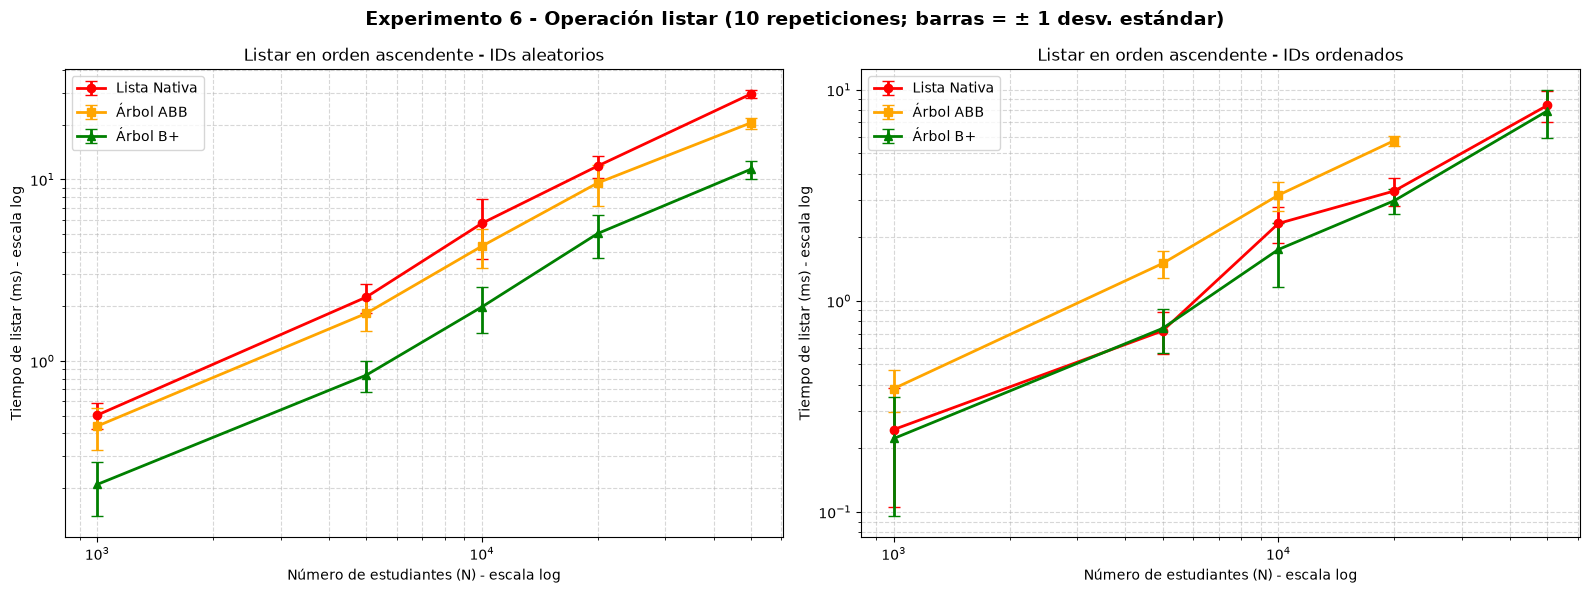

IDs aleatorios:
Media ± desv. estándar [mediana], en ms
         N |              Lista               |               ABB                |                B+               
      1000 |     0.5042 ± 0.081 [0.5021]      |      0.4386 ± 0.12 [0.4234]      |     0.2094 ± 0.069 [0.1858]     
      5000 |       2.247 ± 0.41 [2.422]       |       1.83 ± 0.38 [1.714]        |      0.8359 ± 0.16 [0.7954]     
     10000 |       5.734 ± 2.1 [5.359]        |        4.292 ± 1 [3.896]         |       1.988 ± 0.56 [1.927]      
     20000 |       11.86 ± 1.7 [11.28]        |       9.564 ± 2.4 [9.282]        |       5.038 ± 1.3 [4.816]       
     50000 |       29.52 ± 1.4 [29.67]        |       20.48 ± 1.4 [20.71]        |       11.37 ± 1.3 [11.76]       

IDs ordenados:
Media ± desv. estándar [mediana], en ms
         N |              Lista               |               ABB                |                B+               
      1000 |      0.2455 ± 0.14 [0.1899]      |     0.3839 ± 0.088 [0.3423] 

In [24]:
datos = datos_listar
N = datos["N"]
fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

for ax, caso, titulo in ((ejes[0], "aleatorio", "IDs aleatorios"), (ejes[1], "ordenado", "IDs ordenados")):
    graficar_series(ax, N, datos[caso])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Listar en orden ascendente - {titulo}")
    ax.set_xlabel("Número de estudiantes (N) - escala log")
    ax.set_ylabel("Tiempo de listar (ms) - escala log")
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(fontsize=10)
fig.suptitle(f"Experimento 6 - Operación listar ({datos['repeticiones']} repeticiones; barras = ± 1 desv. estándar)", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_grafica("exp6_listar")
plt.show()

for caso in ("aleatorio", "ordenado"):
    print(f"IDs {caso}s:")
    imprimir_tabla("N", N, {"Lista": datos[caso]["lista"], "ABB": datos[caso]["abb"], "B+": datos[caso]["bplus"]}, "ms")

### Experimento 7: Costo de Inserción Incremental en Estructuras Pobladas

El propósito de este experimento es evaluar el rendimiento de la operación de inserción de nuevos registros en estructuras de datos que ya se encuentran previamente pobladas. Dado que en evaluaciones anteriores únicamente se analizó el tiempo de construcción masiva desde cero, este experimento busca aislar y cuantificar el costo computacional real de agregar elementos nuevos (cuyas claves no existen en el sistema) a medida que la estructura de datos subyacente posee una cantidad de elementos ($N$) cada vez mayor.

Se varía $N \in [1,000; 5,000; 10,000; 20,000; 50,000]$ y se fija $K = 1,000$ inserciones. En cada una de las 10 repeticiones se genera un dataset de $N + K$ estudiantes con IDs barajados: los primeros $N$ forman la estructura base y los últimos $K$ son los nuevos (sus IDs no existen en la base y quedan repartidos de forma aleatoria). Solo se mide el tiempo de insertar los $K$ nuevos y se reporta en µs por inserción.

In [25]:
def benchmark_insercion_poblada(tamanos=[1000, 5000, 10000, 20000, 50000], k_nuevos=1000, repeticiones=REPETICIONES):
    print(f"--- EXPERIMENTO: INSERTAR {k_nuevos} ESTUDIANTES NUEVOS EN ESTRUCTURAS YA POBLADAS ---")
    resultados = {"N": tamanos, "K": k_nuevos, "repeticiones": repeticiones, "lista": [], "abb": [], "bplus": []}

    for n in tamanos:
        print(f"Evaluando N = {n}...")
        tiempos = {"lista": [], "abb": [], "bplus": []}

        for _ in range(repeticiones):
            estudiantes = generar_dataset(n + k_nuevos)      # IDs barajados
            base, nuevos = estudiantes[:n], estudiantes[n:]  # los IDs nuevos no están en la base
            lista, abb, bplus = construir_estructuras(base)

            tiempos["lista"].append(cronometrar(insertar_todos, lista, nuevos))
            tiempos["abb"].append(cronometrar(insertar_todos, abb, nuevos))
            tiempos["bplus"].append(cronometrar(insertar_todos, bplus, nuevos))

        escala = 1e6 / k_nuevos   # segundos por lote -> µs por inserción
        for estructura in tiempos:
            resultados[estructura].append(resumen(tiempos[estructura], escala))

        for estructura, nombre in (("lista", "Lista"), ("abb", "ABB  "), ("bplus", "B+   ")):
            r = resultados[estructura][-1]
            print(f"  {nombre} -> Prom: {r['media']:.3f} µs/inserción (±{r['std']:.3f})")
        print()

    return resultados

datos_insercion = benchmark_insercion_poblada()

--- EXPERIMENTO: INSERTAR 1000 ESTUDIANTES NUEVOS EN ESTRUCTURAS YA POBLADAS ---
Evaluando N = 1000...
  Lista -> Prom: 0.259 µs/inserción (±0.087)
  ABB   -> Prom: 3.640 µs/inserción (±0.814)
  B+    -> Prom: 4.819 µs/inserción (±0.472)

Evaluando N = 5000...
  Lista -> Prom: 0.210 µs/inserción (±0.043)
  ABB   -> Prom: 5.090 µs/inserción (±2.302)
  B+    -> Prom: 5.200 µs/inserción (±0.739)

Evaluando N = 10000...
  Lista -> Prom: 0.169 µs/inserción (±0.021)
  ABB   -> Prom: 5.083 µs/inserción (±0.451)
  B+    -> Prom: 5.884 µs/inserción (±0.781)

Evaluando N = 20000...
  Lista -> Prom: 0.134 µs/inserción (±0.021)
  ABB   -> Prom: 6.586 µs/inserción (±0.881)
  B+    -> Prom: 6.324 µs/inserción (±0.778)

Evaluando N = 50000...
  Lista -> Prom: 0.127 µs/inserción (±0.029)
  ABB   -> Prom: 9.370 µs/inserción (±2.248)
  B+    -> Prom: 9.052 µs/inserción (±4.694)



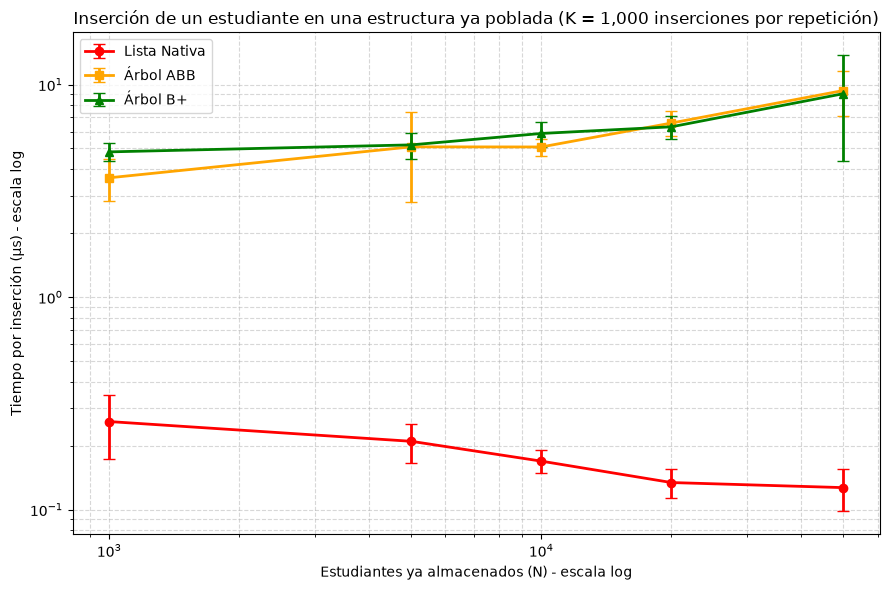

Media ± desv. estándar [mediana], en µs por inserción
         N |              Lista               |               ABB                |                B+               
      1000 |     0.2595 ± 0.087 [0.2393]      |       3.64 ± 0.81 [3.545]        |       4.819 ± 0.47 [4.703]      
      5000 |     0.2095 ± 0.043 [0.2127]      |        5.09 ± 2.3 [4.362]        |        5.2 ± 0.74 [5.028]       
     10000 |      0.169 ± 0.021 [0.171]       |       5.083 ± 0.45 [5.102]       |       5.884 ± 0.78 [6.009]      
     20000 |      0.134 ± 0.021 [0.1292]      |       6.586 ± 0.88 [6.83]        |       6.324 ± 0.78 [6.566]      
     50000 |     0.1269 ± 0.029 [0.1206]      |        9.37 ± 2.2 [8.994]        |       9.052 ± 4.7 [7.538]       



In [26]:
datos = datos_insercion
N = datos["N"]
plt.figure(figsize=(9, 6))
graficar_series(plt.gca(), N, datos)
plt.xscale("log")
plt.yscale("log")
plt.title(f"Inserción de un estudiante en una estructura ya poblada (K = {datos['K']:,} inserciones por repetición)")
plt.xlabel("Estudiantes ya almacenados (N) - escala log")
plt.ylabel("Tiempo por inserción (µs) - escala log")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
guardar_grafica("exp7_insercion_poblada")
plt.show()

imprimir_tabla("N", N, {"Lista": datos["lista"], "ABB": datos["abb"], "B+": datos["bplus"]}, "µs por inserción")

### Experimento 8: Sensibilidad al orden del árbol B+

El propósito de este experimento es analizar la sensibilidad del árbol B+ frente a su parámetro de diseño fundamental: el orden (entendido como la cantidad máxima de claves permitidas por nodo), el cual se había mantenido fijo en un valor de 8 en pruebas previas. Se busca evaluar de qué manera la variación de este parámetro estructural impacta directamente en la altura del árbol, así como en los tiempos computacionales requeridos tanto para su construcción masiva como para la ejecución de operaciones de búsqueda.

Para llevar a cabo este análisis, se fijó el tamaño de la estructura base en $N = 50000$ registros y se definió un lote de evaluación de $M = 5000$ búsquedas por cada iteración. El orden del árbol B+ se varió dentro del conjunto de valores $[4, 8, 16, 32, 64, 128]$. El diseño experimental constó de 10 repeticiones; para asegurar una comparación estricta y controlada, en cada repetición se generó un único conjunto de datos que fue utilizado de manera idéntica para construir y evaluar todos los órdenes propuestos.

In [27]:
def benchmark_orden_bplus(ordenes=[4, 8, 16, 32, 64, 128], n=50000, num_busquedas=5000, repeticiones=REPETICIONES):
    print(f"--- EXPERIMENTO: ORDEN DEL ÁRBOL B+ (N = {n}, M = {num_busquedas}) ---")
    t_busq = {o: [] for o in ordenes}
    t_cons = {o: [] for o in ordenes}
    alturas = {o: [] for o in ordenes}

    for _ in range(repeticiones):
        estudiantes = generar_dataset(n)    # mismo dataset para todos los órdenes (comparación pareada)
        ids_ordenados = sorted(est.Id for est in estudiantes)
        ids = random.choices(ids_ordenados, k=num_busquedas)

        for o in ordenes:
            bplus = BplusTree(order=o)
            t_cons[o].append(cronometrar(insertar_todos, bplus, estudiantes))
            assert [e.Id for e in bplus.listar_ordenado()] == ids_ordenados
            t_busq[o].append(medir_busqueda(bplus, ids))
            alturas[o].append(bplus.altura())

    resultados = {"orden": ordenes, "N": n, "M": num_busquedas, "repeticiones": repeticiones,
                  "busqueda": [resumen(t_busq[o], 1e6 / num_busquedas) for o in ordenes],   # µs por búsqueda
                  "construccion": [resumen(t_cons[o]) for o in ordenes],                    # s
                  "altura": [resumen(alturas[o]) for o in ordenes]}

    for i, o in enumerate(ordenes):
        print(f"  orden {o:4d} | altura {resultados['altura'][i]['media']:.1f}"
              f" | búsqueda {resultados['busqueda'][i]['media']:.3f} µs (±{resultados['busqueda'][i]['std']:.3f})"
              f" | construcción {resultados['construccion'][i]['media']:.3f} s (±{resultados['construccion'][i]['std']:.3f})")
    return resultados

datos_orden = benchmark_orden_bplus()

--- EXPERIMENTO: ORDEN DEL ÁRBOL B+ (N = 50000, M = 5000) ---
  orden    4 | altura 10.3 | búsqueda 6.223 µs (±1.044) | construcción 0.341 s (±0.064)
  orden    8 | altura 6.9 | búsqueda 4.312 µs (±1.360) | construcción 0.183 s (±0.029)
  orden   16 | altura 5.0 | búsqueda 3.224 µs (±1.107) | construcción 0.217 s (±0.065)
  orden   32 | altura 4.0 | búsqueda 2.831 µs (±0.330) | construcción 0.195 s (±0.041)
  orden   64 | altura 3.0 | búsqueda 2.346 µs (±0.295) | construcción 0.253 s (±0.056)
  orden  128 | altura 3.0 | búsqueda 2.616 µs (±0.768) | construcción 0.431 s (±0.115)


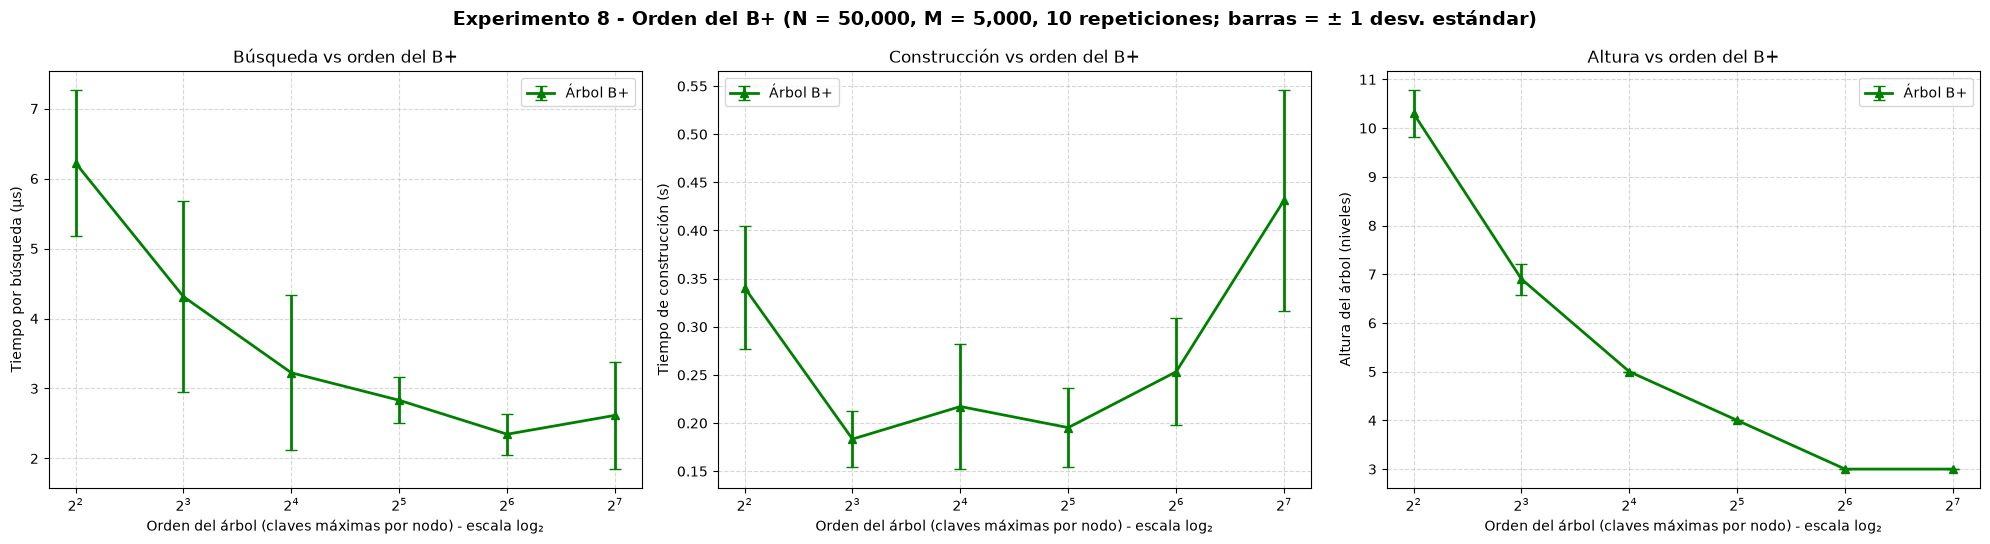

Media ± desv. estándar [mediana], en las unidades de cada columna
     Orden |          Búsqueda (µs)           |         Construcción (s)         |              Altura             
         4 |         6.223 ± 1 [6.53]         |     0.3406 ± 0.064 [0.3402]      |         10.3 ± 0.48 [10]        
         8 |       4.312 ± 1.4 [3.983]        |     0.1834 ± 0.029 [0.1921]      |          6.9 ± 0.32 [7]         
        16 |       3.224 ± 1.1 [3.333]        |     0.2172 ± 0.065 [0.1913]      |            5 ± 0 [5]            
        32 |       2.831 ± 0.33 [2.812]       |     0.1953 ± 0.041 [0.1848]      |            4 ± 0 [4]            
        64 |       2.346 ± 0.29 [2.277]       |     0.2533 ± 0.056 [0.2479]      |            3 ± 0 [3]            
       128 |       2.616 ± 0.77 [2.342]       |      0.4313 ± 0.11 [0.3952]      |            3 ± 0 [3]            



In [28]:
datos = datos_orden
ordenes = datos["orden"]
paneles = (("busqueda", "Tiempo por búsqueda (µs)", "Búsqueda"),
           ("construccion", "Tiempo de construcción (s)", "Construcción"),
           ("altura", "Altura del árbol (niveles)", "Altura"))

fig, ejes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, (clave, ylabel, titulo) in zip(ejes, paneles):
    ax.errorbar(ordenes, [r["media"] for r in datos[clave]], yerr=[r["std"] for r in datos[clave]],
                fmt="-^", color="green", capsize=4, linewidth=2, label="Árbol B+")
    ax.set_xscale("log", base=2)
    ax.set_title(f"{titulo} vs orden del B+")
    ax.set_xlabel("Orden del árbol (claves máximas por nodo) - escala log₂")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()
fig.suptitle(f"Experimento 8 - Orden del B+ (N = {datos['N']:,}, M = {datos['M']:,}, {datos['repeticiones']} repeticiones; barras = ± 1 desv. estándar)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_grafica("exp8_orden_bplus")
plt.show()

imprimir_tabla("Orden", ordenes, {"Búsqueda (µs)": datos["busqueda"], "Construcción (s)": datos["construccion"], "Altura": datos["altura"]}, "las unidades de cada columna")